# ROCO Radiology Multimodal Classification — Keyword-filtered OpenCLIP ResNet50 vs Transformers CLIP ViT-B/32

Notebook này so sánh hai backbone CLIP-style cho bài toán phân loại đa phương thức trên ROCO Radiology:

- **OpenCLIP ResNet50**: `hf-hub:timm/resnet50_clip.openai`, load bằng `open_clip`.
- **CLIP ViT-B/32**: `openai/clip-vit-base-patch32`, load bằng Hugging Face `transformers` với `AutoProcessor` và `AutoModelForZeroShotImageClassification`.

Thay đổi quan trọng trong bản này:

- **Lọc keyword trước khi tạo tập train/val/test dùng cho training/evaluation.**
- Chỉ giữ các mẫu có keyword thuộc nhóm lớp mục tiêu, ví dụ `ct`, `xray_radiograph`, `mri`, `ultrasound`, `angiography`.
- Nhãn classification được lấy từ nhóm keyword đã lọc, không lấy keyword đầu tiên một cách ngẫu nhiên.
- Giữ train/val/test tách biệt; không trộn split khi lọc keyword.

Mục tiêu báo cáo:

- So sánh **zero-shot classification** và **few-shot classification**.
- Dùng cùng bộ metric: accuracy, balanced accuracy, precision, recall, F1, confusion matrix.
- Few-shot chỉ lấy support samples từ train split.


## Dashboard / thông số cần ghi vào báo cáo

Notebook tự sinh `docs/report_dashboard.md` và các file CSV/PNG trong `outputs/` và `docs/plot/`.

Thông số chính:

- Dataset: `/kaggle/input/datasets/shareef0612/roco-radiology`
- Keyword filter: bật trước khi train/val/test; nhãn lấy từ nhóm keyword mục tiêu.
- Target keyword classes: `ct`, `xray_radiograph`, `mri`, `ultrasound`, `angiography`
- ResNet50 branch: `hf-hub:timm/resnet50_clip.openai` qua `open_clip`
- CLIP ViT-B/32 branch: `openai/clip-vit-base-patch32` qua `transformers`
- Task: multimodal classification từ ảnh + caption/report text
- Zero-shot: image/caption embeddings so với class-name prompts
- Few-shot: Logistic Regression trên frozen multimodal features với `k=8` mẫu mỗi lớp
- Metrics: accuracy, balanced accuracy, precision macro/weighted, recall macro/weighted, F1 macro/micro/weighted, confusion matrix


In [1]:
!pip install -q open_clip_torch timm huggingface_hub safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00


In [2]:
# 1. Imports, reproducibility, and paths
import os
import re
import json
import math
import time
import random
import pickle
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display, Markdown

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize, LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    print("PyTorch:", torch.__version__)
except Exception as e:
    raise RuntimeError(
        "Notebook này cần PyTorch. Trên Kaggle, hãy bật Internet hoặc cài `pip install -q torch`."
    ) from e

try:
    import open_clip
    print("open_clip imported successfully")
except Exception as e:
    raise RuntimeError(
        "Notebook này cần `open_clip_torch` để load `hf-hub:timm/resnet50_clip.openai`. "
        "Trên Kaggle, chạy: `pip install -q open_clip_torch timm huggingface_hub safetensors`."
    ) from e

try:
    from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
    import transformers
    print("Transformers:", transformers.__version__)
except Exception as e:
    raise RuntimeError(
        "Notebook này cần Hugging Face Transformers để load CLIP ViT-B/32. "
        "Trên Kaggle, chạy: `pip install -q transformers accelerate safetensors`."
    ) from e

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Torch device:", DEVICE)

# Exact user-provided dataset path and requested model IDs.
DATASET_INPUT_ROOT = Path("/kaggle/input/datasets/shareef0612/roco-radiology")
OPENCLIP_RESNET_MODEL_ID = "hf-hub:timm/resnet50_clip.openai"
TRANSFORMERS_CLIP_MODEL_ID = "openai/clip-vit-base-patch32"

# Backward-compatible names used in later report cells.
CLIP_MODEL_PATH = TRANSFORMERS_CLIP_MODEL_ID
TIMM_RESNET_MODEL_ID = OPENCLIP_RESNET_MODEL_ID
TIMM_RESNET_FALLBACK_ID = "resnet50_clip.openai"

PROJECT_ROOT = Path(".")
OUTDIR = PROJECT_ROOT / "outputs"
MODEL_DIR = PROJECT_ROOT / "models"
PLOT_DIR = PROJECT_ROOT / "docs" / "plot"
REPORT_DIR = PROJECT_ROOT / "docs"
for d in [OUTDIR, MODEL_DIR, PLOT_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CFG = {
    # Dataset
    "dataset_root_hints": [
        DATASET_INPUT_ROOT,
        DATASET_INPUT_ROOT / "ROCO Radiology",
        DATASET_INPUT_ROOT / "ROCO Radiology" / "ROCO Radiology",
        Path("/kaggle/input/roco-radiology"),
        Path("/kaggle/input/roco-radiology/ROCO Radiology"),
        Path("/kaggle/input"),
        Path("."),
    ],
    "train_csv": "train_data.csv",
    "val_csv": "val_data.csv",
    "test_csv": "test_data.csv",
    "image_root": "images",
    "split_to_dir": {"train": "train_set", "val": "val_set", "test": "test_set"},
    "id_col": "ROCO_ID",
    "image_col": "PMC_ID",
    "keywords_col": "Keywords",
    "caption_col": "Caption",

    # Classification target
    "label_col": None,
    "label_col_candidates": [
        "Modality", "modality", "MODALITY",
        "Category", "category", "Class", "class",
        "Label", "label", "Labels", "labels",
        "SubCategory", "sub_category", "BodyPart", "body_part",
        "Organ", "organ", "Projection", "projection",
    ],
"derive_label_from_keywords": True,

# Keyword filtering before train/validation/test processing.
# ROCO CSVs contain a comma-separated `Keywords` column.  We convert selected
# keywords into stable classification labels, then drop samples that do not
# contain any target keyword.  This avoids noisy labels such as "arrow",
# "right", "image", or the first arbitrary keyword in each row.
"enable_keyword_filter": True,
"keyword_label_col": "keyword_label",
"keep_rows_without_target_keyword": False,
"target_keyword_groups": {
    "ct": ["ct", "tomography", "computed tomography"],
    "xray_radiograph": ["xray", "x-ray", "radiograph", "radiographic", "anteroposterior"],
    "mri": ["mri", "magnetic", "resonance", "magnetic resonance"],
    "ultrasound": ["ultrasound", "sonograph", "sonographic", "sonography"],
    "angiography": ["angiography", "angiogram", "arteriography"],
},
"keyword_group_priority": ["ct", "xray_radiograph", "mri", "ultrasound", "angiography"],
"use_caption_fallback_for_keywords": True,
    "max_classes": 5,
    "min_train_per_class": 8,
    "drop_duplicate_pairs": True,

    # Models
    "models": ["OpenCLIP-ResNet50", "CLIP-ViT-B/32"],
    "openclip_resnet_model_id": OPENCLIP_RESNET_MODEL_ID,
    "clip_model_id": TRANSFORMERS_CLIP_MODEL_ID,
    # Backward-compatible keys used by later cells.
    "clip_model_path": TRANSFORMERS_CLIP_MODEL_ID,
    "timm_resnet_model_id": OPENCLIP_RESNET_MODEL_ID,
    "timm_resnet_fallback_id": TIMM_RESNET_FALLBACK_ID,
    "image_size": 224,
    "common_dim": 128,
    "multimodal_text_weight": 0.35,

    # Zero-shot / few-shot classification
    "k_shots": [0, 8],
    "few_shot_k": 8,
    "max_iter_classifier": 1000,
    "class_weight": "balanced",

    # Feature extraction
    "feature_batch_size": 32,
    "text_batch_size": 128,

    # Runtime controls for Kaggle. Set to None for full run.
    "fast_dev_run": False,
    "max_train_rows": None,
    "max_val_rows": None,
    "max_test_rows": None,
    "max_eval_items": None,
    "run_resnet": True,
    "run_clip_vit": True,
}

print("Dataset root hint:", DATASET_INPUT_ROOT)
print("OpenCLIP ResNet model:", OPENCLIP_RESNET_MODEL_ID)
print("Transformers CLIP ViT model:", TRANSFORMERS_CLIP_MODEL_ID)
print("Output directories ready.")


PyTorch: 2.10.0+cu128
open_clip imported successfully
Transformers: 5.0.0
Torch device: cuda
Dataset root hint: /kaggle/input/datasets/shareef0612/roco-radiology
OpenCLIP ResNet model: hf-hub:timm/resnet50_clip.openai
Transformers CLIP ViT model: openai/clip-vit-base-patch32
Output directories ready.


In [3]:
# 2. Resolve ROCO dataset root and read CSVs
IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]


def find_dataset_root(cfg):
    required = {cfg["train_csv"], cfg["val_csv"], cfg["test_csv"]}
    candidates = []

    for hint in cfg["dataset_root_hints"]:
        p = Path(hint)
        if p.exists():
            files = {x.name for x in p.glob("*.csv")}
            if required.issubset(files):
                candidates.append(p)

    # Recursive fallback for Kaggle nested layouts.
    for base in [DATASET_INPUT_ROOT, Path("/kaggle/input"), Path(".")]:
        if base.exists():
            for train_file in base.rglob(cfg["train_csv"]):
                parent = train_file.parent
                files = {x.name for x in parent.glob("*.csv")}
                if required.issubset(files):
                    candidates.append(parent)

    if not candidates:
        raise FileNotFoundError(
            "Không tìm thấy thư mục chứa train_data.csv, val_data.csv, test_data.csv. "
            "Kiểm tra lại Kaggle input dataset path."
        )

    # Prefer directories with images/ and shorter path.
    candidates = sorted(set(candidates), key=lambda x: (not (x / cfg["image_root"]).exists(), len(str(x))))
    return candidates[0]


DATA_ROOT = find_dataset_root(CFG)
TRAIN_CSV = DATA_ROOT / CFG["train_csv"]
VAL_CSV = DATA_ROOT / CFG["val_csv"]
TEST_CSV = DATA_ROOT / CFG["test_csv"]
IMAGE_ROOT = DATA_ROOT / CFG["image_root"]

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_CSV:", TRAIN_CSV)
print("VAL_CSV:", VAL_CSV)
print("TEST_CSV:", TEST_CSV)
print("IMAGE_ROOT:", IMAGE_ROOT)
print("Split image dirs:", {k: str(IMAGE_ROOT / v) for k, v in CFG["split_to_dir"].items()})

train_raw = pd.read_csv(TRAIN_CSV)
val_raw = pd.read_csv(VAL_CSV)
test_raw = pd.read_csv(TEST_CSV)

print("Raw shapes:", train_raw.shape, val_raw.shape, test_raw.shape)
print("Columns:", list(train_raw.columns))
display(train_raw.head(3))

required_cols = [CFG["id_col"], CFG["image_col"], CFG["caption_col"]]
if CFG["keywords_col"] in train_raw.columns:
    required_cols.append(CFG["keywords_col"])

for df_name, df in [("train", train_raw), ("val", val_raw), ("test", test_raw)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name}_data.csv thiếu cột: {missing}. Columns hiện có: {list(df.columns)}")


DATA_ROOT: /kaggle/input/datasets/shareef0612/roco-radiology/ROCO Radiology
TRAIN_CSV: /kaggle/input/datasets/shareef0612/roco-radiology/ROCO Radiology/train_data.csv
VAL_CSV: /kaggle/input/datasets/shareef0612/roco-radiology/ROCO Radiology/val_data.csv
TEST_CSV: /kaggle/input/datasets/shareef0612/roco-radiology/ROCO Radiology/test_data.csv
IMAGE_ROOT: /kaggle/input/datasets/shareef0612/roco-radiology/ROCO Radiology/images
Split image dirs: {'train': '/kaggle/input/datasets/shareef0612/roco-radiology/ROCO Radiology/images/train_set', 'val': '/kaggle/input/datasets/shareef0612/roco-radiology/ROCO Radiology/images/val_set', 'test': '/kaggle/input/datasets/shareef0612/roco-radiology/ROCO Radiology/images/test_set'}
Raw shapes: (65448, 4) (8180, 4) (8179, 4)
Columns: ['ROCO_ID', 'PMC_ID', 'Keywords', 'Caption']


,ROCO_ID,PMC_ID,Keywords,Caption
0,ROCO_00002,PMC4083729_AMHSR-4-14-g002.jpg,"scan,maxillary,sinu,axial,tomography,obliterat...",Computed tomography scan in axial view showin...
1,ROCO_00003,PMC2837471_IJD2009-150251.001.jpg,"canal,completion,temporary,month,filling,treat...",Bacterial contamination occurred after comple...
2,ROCO_00004,PMC2505281_11999_2007_30_Fig6_HTML.jpg,"poliomyeliti,index,healing,necessary,complete,...",The patient had residual paralysis of the han...


In [4]:
# 3. Keyword filtering, image path resolution, and classification label construction

def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def normalize_label(x):
    x = clean_text(x).lower()
    x = re.sub(r"[_\-/]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def keyword_tokens(x):
    """Return normalized keyword tokens from ROCO's comma-separated Keywords column."""
    x = clean_text(x).lower()
    if not x:
        return []
    # ROCO keywords are usually comma-separated, but this also handles semicolon/pipe/slash.
    parts = [normalize_label(p) for p in re.split(r"[;,|/]+", x) if normalize_label(p)]
    return parts


def match_keyword_group(row, cfg=CFG):
    """Map raw ROCO keywords/caption to one target class.

    The mapping is priority-based to keep a single-label classification task.
    Exact keyword tokens are used first.  Optional caption fallback catches full
    phrases such as "computed tomography" when a keyword field is incomplete.
    """
    tokens = set(keyword_tokens(row.get(cfg["keywords_col"], "")))
    caption_norm = normalize_label(row.get(cfg["caption_col"], ""))
    matched = []

    for label in cfg["keyword_group_priority"]:
        terms = cfg["target_keyword_groups"].get(label, [])
        term_norms = [normalize_label(t) for t in terms]

        token_hit = any(t in tokens for t in term_norms)
        caption_hit = False
        if cfg.get("use_caption_fallback_for_keywords", False):
            caption_hit = any(re.search(rf"\b{re.escape(t)}\b", caption_norm) for t in term_norms if t)

        if token_hit or caption_hit:
            matched = [t for t in term_norms if (t in tokens or (caption_norm and re.search(rf"\b{re.escape(t)}\b", caption_norm)))]
            return label, ",".join(matched)

    return "", ""


def apply_keyword_filter(raw_df, split_name, cfg=CFG):
    """Filter rows by target keywords before any train/val/test sampling or model work."""
    df = raw_df.copy()
    before = len(df)

    if cfg.get("enable_keyword_filter", False):
        matches = df.apply(lambda row: match_keyword_group(row, cfg), axis=1)
        df[cfg["keyword_label_col"]] = [m[0] for m in matches]
        df["matched_keywords"] = [m[1] for m in matches]

        if cfg.get("keep_rows_without_target_keyword", False):
            df[cfg["keyword_label_col"]] = df[cfg["keyword_label_col"]].replace("", "other")
        else:
            df = df[df[cfg["keyword_label_col"]].astype(str).str.len() > 0].copy()

        after = len(df)
        print(f"{split_name}: keyword filter kept {after:,}/{before:,} rows ({after / max(before, 1):.2%})")
    else:
        df[cfg["keyword_label_col"]] = ""
        df["matched_keywords"] = ""
        after = len(df)
        print(f"{split_name}: keyword filter disabled; kept {after:,}/{before:,} rows")

    return df.reset_index(drop=True)


def build_image_lookup(root):
    """Index images by filename and stem so the notebook works for nested or flat ROCO layouts."""
    lookup = {}
    root = Path(root)
    if not root.exists():
        return lookup
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            lookup.setdefault(p.name, str(p))
            lookup.setdefault(p.stem, str(p))
    return lookup


IMAGE_LOOKUP = build_image_lookup(IMAGE_ROOT)
print("Indexed image keys under IMAGE_ROOT:", len(IMAGE_LOOKUP))


def find_image_path(value, folder):
    """Resolve PMC_ID to an existing image path. Handles flat, split, nested, with/without extension."""
    value = str(value).strip()
    if not value:
        return None
    p = Path(value)
    candidates = []
    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.extend([Path(folder) / value, IMAGE_ROOT / value])
    if p.suffix == "":
        for ext in IMAGE_EXTS:
            candidates.extend([Path(folder) / f"{value}{ext}", IMAGE_ROOT / f"{value}{ext}"])
    for c in candidates:
        if c.exists():
            return str(c)
    if value in IMAGE_LOOKUP:
        return IMAGE_LOOKUP[value]
    if p.stem in IMAGE_LOOKUP:
        return IMAGE_LOOKUP[p.stem]
    # Return the direct split path for audit even if missing.
    return str(Path(folder) / value)


def infer_label_source(train_df, val_df, test_df, cfg):
    if cfg.get("enable_keyword_filter", False) and cfg.get("keyword_label_col") in train_df.columns:
        return cfg["keyword_label_col"], "keyword_filter_group"

    if cfg["label_col"] is not None:
        if cfg["label_col"] not in train_df.columns:
            raise ValueError(f"CFG['label_col'] = {cfg['label_col']} nhưng cột này không tồn tại.")
        return cfg["label_col"], "csv_column"

    all_cols = list(train_df.columns)
    for col in cfg["label_col_candidates"]:
        if col in all_cols:
            n_unique = train_df[col].dropna().astype(str).map(normalize_label).nunique()
            n_rows = max(len(train_df), 1)
            if 2 <= n_unique <= max(cfg["max_classes"] * 5, 20) and n_unique < 0.5 * n_rows:
                return col, "csv_column_auto"

    if cfg["derive_label_from_keywords"] and cfg["keywords_col"] in train_df.columns:
        return cfg["keywords_col"], "keyword_primary"

    raise ValueError(
        "Không tìm thấy cột nhãn phù hợp. Hãy đặt CFG['label_col'] bằng tên cột nhãn trong CSV."
    )


def keyword_to_primary_label(x):
    x = clean_text(x)
    if not x:
        return ""
    parts = [p.strip() for p in re.split(r"[;,|]", x) if p.strip()]
    if not parts:
        parts = [x]
    label = normalize_label(parts[0])
    label = " ".join(label.split()[:6])
    return label


# Apply keyword filtering to each original split before image resolution, sampling, class selection, or training.
train_keyword_raw = apply_keyword_filter(train_raw, "train")
val_keyword_raw = apply_keyword_filter(val_raw, "val")
test_keyword_raw = apply_keyword_filter(test_raw, "test")

LABEL_SOURCE_COL, LABEL_SOURCE_MODE = infer_label_source(train_keyword_raw, val_keyword_raw, test_keyword_raw, CFG)
print("LABEL_SOURCE_COL:", LABEL_SOURCE_COL)
print("LABEL_SOURCE_MODE:", LABEL_SOURCE_MODE)


def extract_label(row):
    if LABEL_SOURCE_MODE == "keyword_filter_group":
        # Keep configured class names such as xray_radiograph stable for reports/files.
        return clean_text(row.get(CFG["keyword_label_col"], "")).lower()
    if LABEL_SOURCE_MODE.startswith("csv_column") and LABEL_SOURCE_COL != CFG["keywords_col"]:
        return normalize_label(row.get(LABEL_SOURCE_COL, ""))
    return keyword_to_primary_label(row.get(CFG["keywords_col"], ""))


def prepare_split(raw_df, split_name):
    df = raw_df.copy()
    folder = IMAGE_ROOT / CFG["split_to_dir"].get(split_name, split_name)
    df["split"] = split_name
    df["sample_id"] = df[CFG["id_col"]].astype(str)
    df["caption"] = df[CFG["caption_col"]].map(clean_text)
    df["keywords"] = df[CFG["keywords_col"]].map(clean_text) if CFG["keywords_col"] in df.columns else ""
    df["label"] = df.apply(extract_label, axis=1)
    df["image_path"] = df[CFG["image_col"]].apply(lambda x: find_image_path(x, folder))
    df["image_exists"] = df["image_path"].apply(lambda p: Path(p).exists() if isinstance(p, str) else False)
    df["caption_len"] = df["caption"].str.len()
    df = df[(df["caption"].str.len() > 0) & (df["image_exists"]) & (df["label"].str.len() > 0)].reset_index(drop=True)
    if CFG["drop_duplicate_pairs"]:
        before = len(df)
        df = df.drop_duplicates(subset=["image_path", "caption", "label"]).reset_index(drop=True)
        print(f"{split_name}: dropped {before - len(df)} duplicate image-caption-label rows")
    df["pair_id"] = [f"{split_name}_{i:06d}" for i in range(len(df))]
    return df


train_pairs_df = prepare_split(train_keyword_raw, "train")
val_pairs_df = prepare_split(val_keyword_raw, "val")
test_pairs_df = prepare_split(test_keyword_raw, "test")

if CFG["fast_dev_run"]:
    train_pairs_df = train_pairs_df.sample(n=min(len(train_pairs_df), 512), random_state=SEED).reset_index(drop=True)
    val_pairs_df = val_pairs_df.sample(n=min(len(val_pairs_df), 256), random_state=SEED).reset_index(drop=True)
    test_pairs_df = test_pairs_df.sample(n=min(len(test_pairs_df), 256), random_state=SEED).reset_index(drop=True)
else:
    if CFG["max_train_rows"] is not None:
        train_pairs_df = train_pairs_df.sample(n=min(len(train_pairs_df), CFG["max_train_rows"]), random_state=SEED).reset_index(drop=True)
    if CFG["max_val_rows"] is not None:
        val_pairs_df = val_pairs_df.sample(n=min(len(val_pairs_df), CFG["max_val_rows"]), random_state=SEED).reset_index(drop=True)
    if CFG["max_test_rows"] is not None:
        test_pairs_df = test_pairs_df.sample(n=min(len(test_pairs_df), CFG["max_test_rows"]), random_state=SEED).reset_index(drop=True)

# Keep classes that exist in train and preserve the configured keyword priority/order.
train_counts = train_pairs_df["label"].value_counts()
if LABEL_SOURCE_MODE == "keyword_filter_group":
    ordered_candidates = [clean_text(c).lower() for c in CFG["keyword_group_priority"] if clean_text(c).lower() in train_counts.index]
    candidate_classes = [c for c in ordered_candidates if train_counts[c] >= CFG["min_train_per_class"]]
    if len(candidate_classes) < 2:
        candidate_classes = ordered_candidates[:max(2, CFG["max_classes"])]
else:
    candidate_classes = train_counts[train_counts >= CFG["min_train_per_class"]].head(CFG["max_classes"]).index.tolist()
    if len(candidate_classes) < 2:
        candidate_classes = train_counts.head(max(2, CFG["max_classes"])).index.tolist()

candidate_classes = candidate_classes[:CFG["max_classes"]]


def filter_classes(df, classes):
    return df[df["label"].isin(classes)].reset_index(drop=True)


train_pairs_df = filter_classes(train_pairs_df, candidate_classes)
val_pairs_df = filter_classes(val_pairs_df, candidate_classes)
test_pairs_df = filter_classes(test_pairs_df, candidate_classes)

# Evaluation set: by default use the full filtered test split.
eval_pairs_df = test_pairs_df.copy().reset_index(drop=True)
if CFG["max_eval_items"] is not None:
    eval_pairs_df = eval_pairs_df.sample(n=min(len(eval_pairs_df), CFG["max_eval_items"]), random_state=SEED).reset_index(drop=True)
eval_pairs_df["eval_index"] = np.arange(len(eval_pairs_df))

# Final class order must match score matrix columns.  Use explicit dict mappings instead of LabelEncoder
# so class IDs cannot silently reorder alphabetically.
class_names = [c for c in candidate_classes if c in set(train_pairs_df["label"])]
class_to_id = {c: i for i, c in enumerate(class_names)}
id_to_class = {i: c for c, i in class_to_id.items()}
label_encoder = None  # kept only for backward compatibility; y_to_int/int_to_y use class_to_id.

for name, df in [("train", train_pairs_df), ("val", val_pairs_df), ("test", test_pairs_df), ("eval", eval_pairs_df)]:
    if len(df) == 0:
        raise ValueError(f"{name} split rỗng sau khi lọc keyword/lớp. Hãy kiểm tra CFG['target_keyword_groups'] hoặc giảm min_train_per_class.")
    unknown = sorted(set(df["label"]) - set(class_names))
    if unknown:
        raise ValueError(f"{name} có nhãn không nằm trong class_names: {unknown[:5]}")

all_df = pd.concat([train_pairs_df, val_pairs_df, test_pairs_df], ignore_index=True)
split_summary = all_df.groupby("split").agg(
    samples=("sample_id", "count"),
    unique_images=("image_path", "nunique"),
    unique_captions=("caption", "nunique"),
    num_classes=("label", "nunique"),
    mean_caption_len=("caption_len", "mean"),
).reset_index()

class_distribution = (
    all_df.groupby(["split", "label"]).size().reset_index(name="count")
    .sort_values(["split", "count"], ascending=[True, False])
)

keyword_filter_summary = pd.DataFrame([
    {
        "split": "train",
        "rows_before_keyword_filter": len(train_raw),
        "rows_after_keyword_filter": len(train_keyword_raw),
        "rows_after_image_and_class_filter": len(train_pairs_df),
    },
    {
        "split": "val",
        "rows_before_keyword_filter": len(val_raw),
        "rows_after_keyword_filter": len(val_keyword_raw),
        "rows_after_image_and_class_filter": len(val_pairs_df),
    },
    {
        "split": "test",
        "rows_before_keyword_filter": len(test_raw),
        "rows_after_keyword_filter": len(test_keyword_raw),
        "rows_after_image_and_class_filter": len(test_pairs_df),
    },
])
keyword_filter_summary["keyword_filter_keep_rate"] = (
    keyword_filter_summary["rows_after_keyword_filter"] / keyword_filter_summary["rows_before_keyword_filter"].clip(lower=1)
)

keyword_class_distribution = (
    pd.concat([
        train_keyword_raw.assign(split="train"),
        val_keyword_raw.assign(split="val"),
        test_keyword_raw.assign(split="test"),
    ], ignore_index=True)
    .groupby(["split", CFG["keyword_label_col"]])
    .size()
    .reset_index(name="rows_after_keyword_filter")
    .rename(columns={CFG["keyword_label_col"]: "keyword_label"})
    .sort_values(["split", "rows_after_keyword_filter"], ascending=[True, False])
)

evaluation_protocol = pd.DataFrame([
    {"item": "task", "value": "Multimodal classification"},
    {"item": "keyword_filter", "value": "enabled" if CFG["enable_keyword_filter"] else "disabled"},
    {"item": "target_keyword_groups", "value": json.dumps(CFG["target_keyword_groups"], ensure_ascii=False)},
    {"item": "label_source", "value": f"{LABEL_SOURCE_MODE}: {LABEL_SOURCE_COL}"},
    {"item": "classes", "value": ", ".join(class_names)},
    {"item": "num_classes", "value": len(class_names)},
    {"item": "zero_shot", "value": "No classifier training; both CLIP-style models use image/caption embeddings against class-name prompts."},
    {"item": "few_shot", "value": f"Train a lightweight classifier with {CFG['few_shot_k']} samples per class from the keyword-filtered train split."},
    {"item": "metrics", "value": "Accuracy, precision, recall, F1, balanced accuracy, confusion matrix."},
])

display(keyword_filter_summary)
display(keyword_class_distribution)
display(split_summary)
display(class_distribution.head(30))
display(evaluation_protocol)
print("Class names:", class_names)
print("Train / Val / Test / Eval:", len(train_pairs_df), len(val_pairs_df), len(test_pairs_df), len(eval_pairs_df))

keyword_filter_summary.to_csv(OUTDIR / "keyword_filter_summary.csv", index=False)
keyword_class_distribution.to_csv(OUTDIR / "keyword_class_distribution.csv", index=False)
split_summary.to_csv(OUTDIR / "dataset_summary.csv", index=False)
class_distribution.to_csv(OUTDIR / "class_distribution.csv", index=False)
evaluation_protocol.to_csv(OUTDIR / "classification_protocol.csv", index=False)


Indexed image keys under IMAGE_ROOT: 163542
train: keyword filter kept 38,092/65,448 rows (58.20%)
val: keyword filter kept 4,752/8,180 rows (58.09%)
test: keyword filter kept 4,820/8,179 rows (58.93%)
LABEL_SOURCE_COL: keyword_label
LABEL_SOURCE_MODE: keyword_filter_group
train: dropped 0 duplicate image-caption-label rows
val: dropped 0 duplicate image-caption-label rows
test: dropped 0 duplicate image-caption-label rows


,split,rows_before_keyword_filter,rows_after_keyword_filter,rows_after_image_and_class_filter,keyword_filter_keep_rate
0,train,65448,38092,38072,0.582019
1,val,8180,4752,4749,0.580929
2,test,8179,4820,4818,0.589314


,split,keyword_label,rows_after_keyword_filter
1,test,ct,2104
4,test,xray_radiograph,1371
2,test,mri,803
3,test,ultrasound,296
0,test,angiography,246
6,train,ct,16636
9,train,xray_radiograph,10965
7,train,mri,6388
8,train,ultrasound,2241
5,train,angiography,1862


,split,samples,unique_images,unique_captions,num_classes,mean_caption_len
0,test,4818,4818,4806,5,143.937318
1,train,38072,38072,37611,5,140.680290
2,val,4749,4749,4731,5,139.902716


,split,label,count
1,test,ct,2103
4,test,xray_radiograph,1371
2,test,mri,802
3,test,ultrasound,296
0,test,angiography,246
6,train,ct,16623
9,train,xray_radiograph,10963
7,train,mri,6384
8,train,ultrasound,2241
5,train,angiography,1861


,item,value
0,task,Multimodal classification
1,keyword_filter,enabled
2,target_keyword_groups,"{""ct"": [""ct"", ""tomography"", ""computed tomograp..."
3,label_source,keyword_filter_group: keyword_label
4,classes,"ct, xray_radiograph, mri, ultrasound, angiography"
5,num_classes,5
6,zero_shot,No classifier training; both CLIP-style models...
7,few_shot,Train a lightweight classifier with 8 samples ...
8,metrics,"Accuracy, precision, recall, F1, balanced accu..."


Class names: ['ct', 'xray_radiograph', 'mri', 'ultrasound', 'angiography']
Train / Val / Test / Eval: 38072 4749 4818 4818


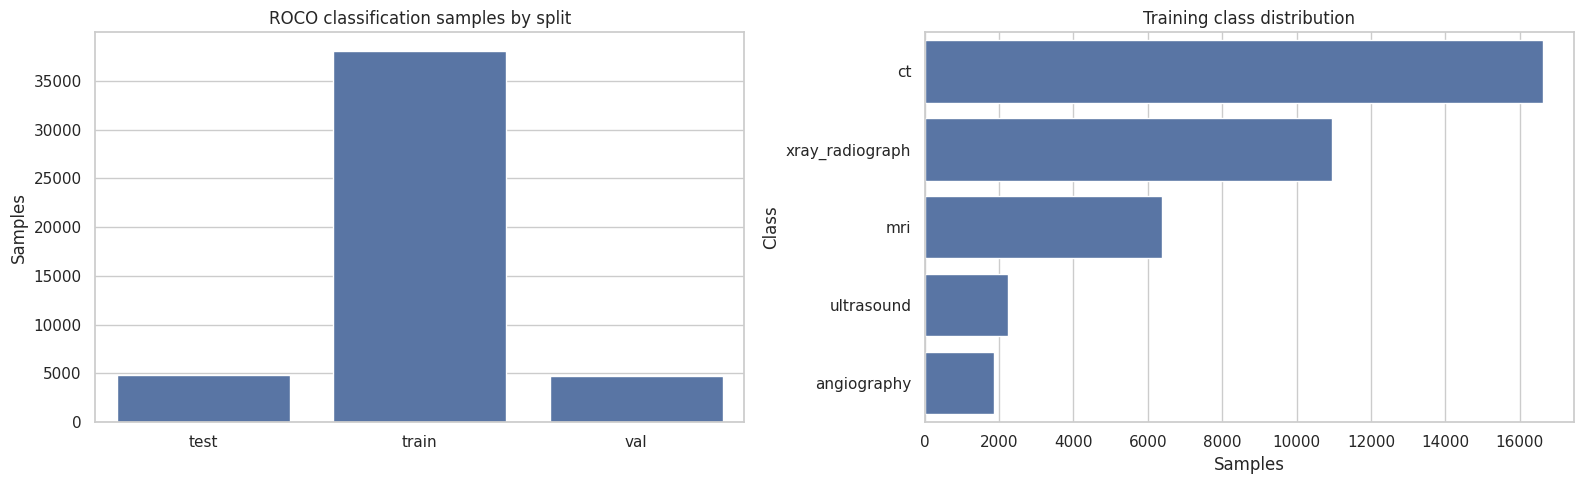

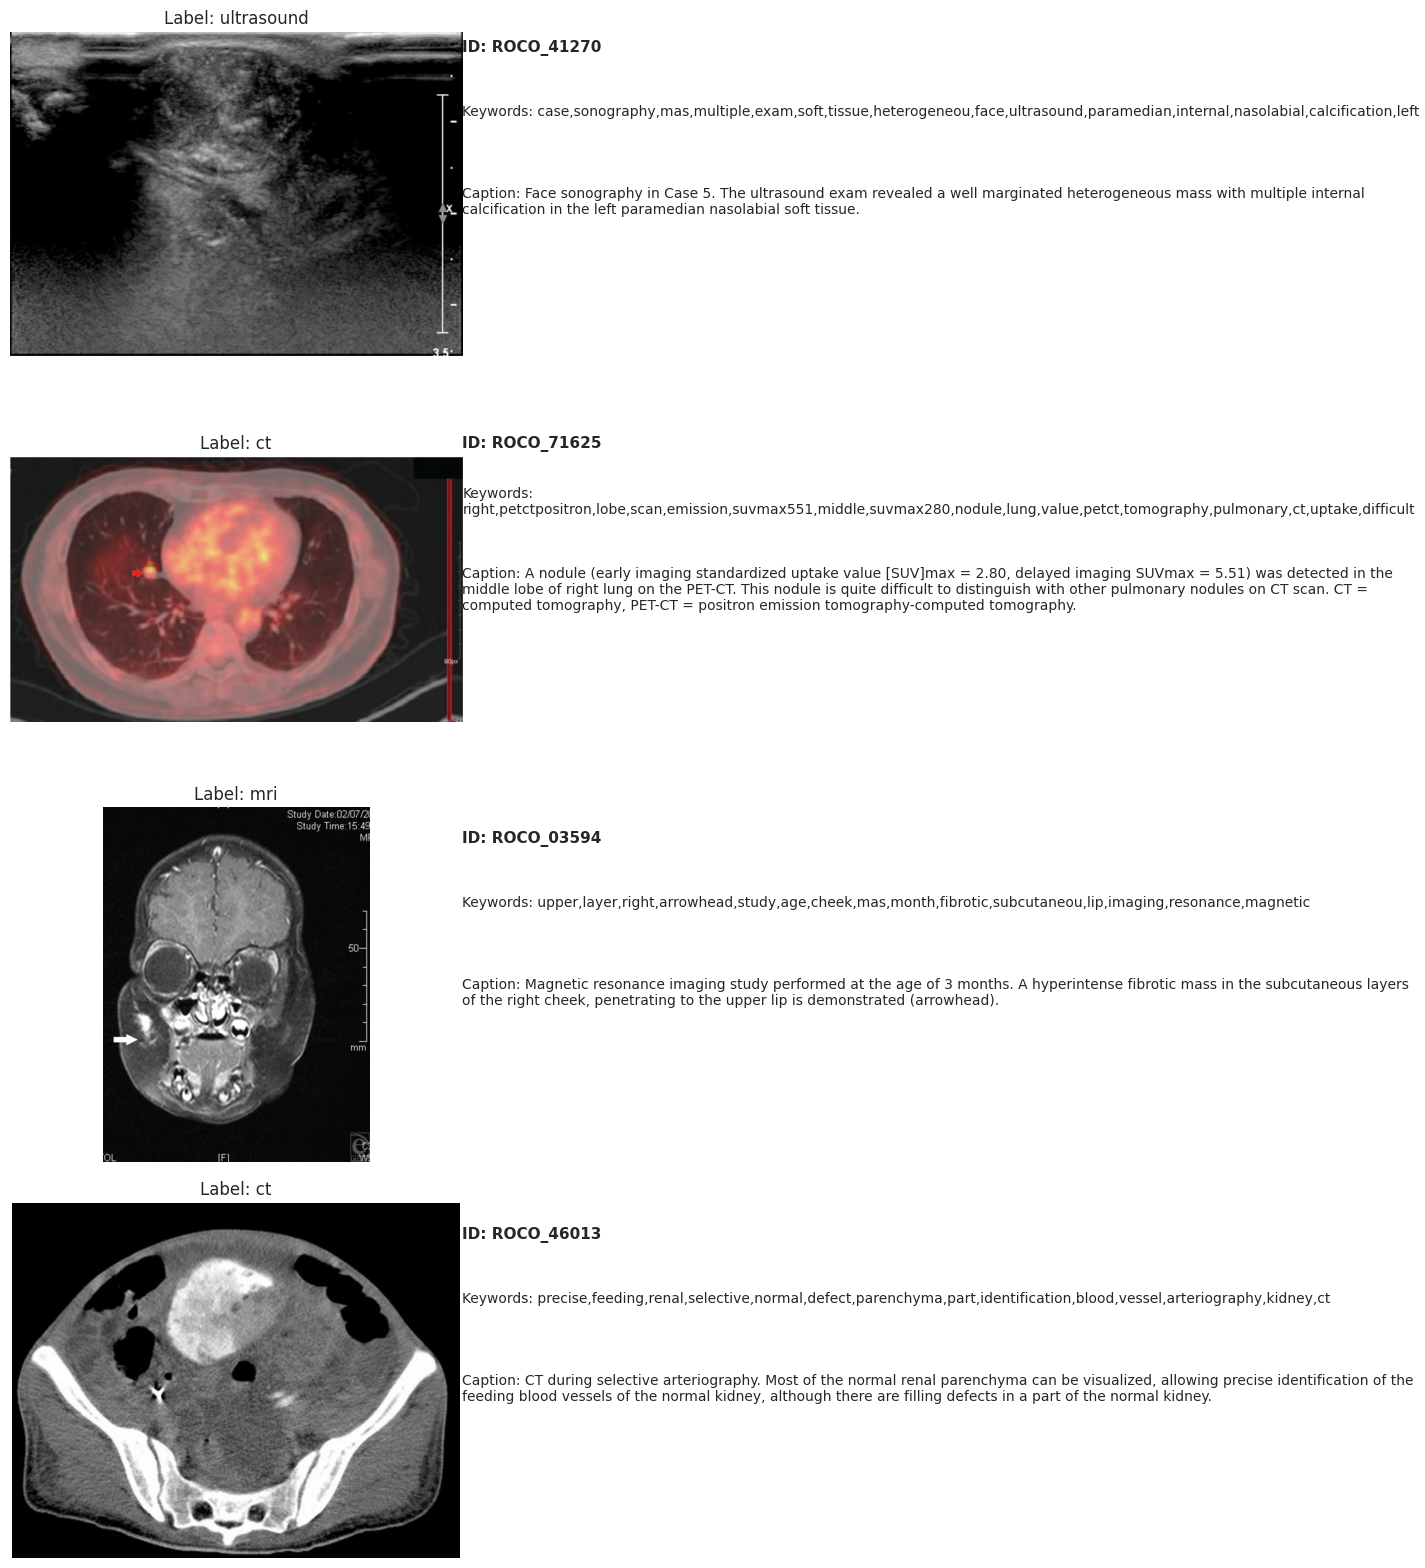

In [5]:
# 4. EDA for report
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=split_summary, x="split", y="samples", ax=axes[0])
axes[0].set_title("ROCO classification samples by split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Samples")

train_dist = class_distribution[class_distribution["split"] == "train"]
sns.barplot(data=train_dist, y="label", x="count", ax=axes[1])
axes[1].set_title("Training class distribution")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Class")

plt.tight_layout()
plt.savefig(PLOT_DIR / "eda_distribution.png", dpi=160)
plt.show()

# Show sample image-caption-label pairs.
sample_show = train_pairs_df.sample(n=min(4, len(train_pairs_df)), random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(len(sample_show), 2, figsize=(14, 4 * len(sample_show)))
if len(sample_show) == 1:
    axes = np.array([axes])
for i, row in sample_show.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].axis("off")
    axes[i, 0].set_title(f"Label: {row['label']}")
    axes[i, 1].axis("off")
    axes[i, 1].text(0, 0.9, f"ID: {row['sample_id']}", fontsize=11, weight="bold")
    axes[i, 1].text(0, 0.72, f"Keywords: {row['keywords'][:240]}", fontsize=10, wrap=True)
    axes[i, 1].text(0, 0.45, f"Caption: {row['caption'][:520]}", fontsize=10, wrap=True)
plt.tight_layout()
plt.savefig(PLOT_DIR / "sample_pairs.png", dpi=160)
plt.show()


In [6]:
# 5. Generic utilities and classification metrics

def load_image_array(path, image_size=224):
    img = Image.open(path).convert("RGB").resize((image_size, image_size))
    return np.asarray(img, dtype=np.float32)


def batched(items, batch_size):
    for i in range(0, len(items), batch_size):
        yield items[i:i + batch_size]


def l2norm(x):
    x = np.asarray(x, dtype=np.float32)
    return normalize(x, norm="l2", axis=1)


def unique_in_order(values):
    seen = set()
    out = []
    for v in values:
        if v not in seen:
            out.append(v)
            seen.add(v)
    return out


def class_prompts(names):
    prompts = []
    for label in names:
        label_clean = str(label).replace("_", " ")
        prompts.extend([
            f"a radiology image showing {label_clean}",
            f"a medical imaging study of {label_clean}",
            f"radiology findings related to {label_clean}",
        ])
    return prompts


def aggregate_prompt_scores(prompt_scores, n_classes, prompts_per_class=3):
    # prompt_scores shape: [n_samples, n_classes * prompts_per_class]
    scores = prompt_scores.reshape(prompt_scores.shape[0], n_classes, prompts_per_class)
    return scores.mean(axis=2)


def y_to_int(labels):
    """Map labels to IDs using the explicit class_names order.

    This avoids LabelEncoder's automatic alphabetical sorting, which can break
    alignment between zero-shot score columns and class IDs.
    """
    labels = list(labels)
    missing = sorted(set(labels) - set(class_to_id))
    if missing:
        raise ValueError(f"Unknown labels encountered: {missing[:10]}")
    return np.asarray([class_to_id[x] for x in labels], dtype=int)


def int_to_y(ids):
    ids = np.asarray(ids, dtype=int)
    return np.asarray([id_to_class[int(i)] for i in ids])


def metric_dict(y_true_int, y_pred_int, elapsed_s, n_samples):
    return {
        "accuracy": float(accuracy_score(y_true_int, y_pred_int)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true_int, y_pred_int)),
        "precision_macro": float(precision_score(y_true_int, y_pred_int, average="macro", zero_division=0)),
        "precision_weighted": float(precision_score(y_true_int, y_pred_int, average="weighted", zero_division=0)),
        "recall_macro": float(recall_score(y_true_int, y_pred_int, average="macro", zero_division=0)),
        "recall_weighted": float(recall_score(y_true_int, y_pred_int, average="weighted", zero_division=0)),
        "f1_macro": float(f1_score(y_true_int, y_pred_int, average="macro", zero_division=0)),
        "f1_micro": float(f1_score(y_true_int, y_pred_int, average="micro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true_int, y_pred_int, average="weighted", zero_division=0)),
        "time_s": float(elapsed_s),
        "time_per_sample_ms": float((elapsed_s / max(n_samples, 1)) * 1000),
        "eval_samples": int(n_samples),
    }


def save_classification_outputs(model_name, shots, y_true_int, y_pred_int, pred_scores=None, extra_df=None):
    slug = model_name.lower().replace("/", "_").replace("-", "_").replace(" ", "_")
    mode_slug = f"{shots}shot"

    pred_df = eval_pairs_df[["pair_id", "sample_id", "image_path", "caption", "keywords", "label"]].copy().reset_index(drop=True)
    pred_df["true_label"] = int_to_y(y_true_int)
    pred_df["pred_label"] = int_to_y(y_pred_int)
    pred_df["is_correct"] = pred_df["true_label"] == pred_df["pred_label"]
    if pred_scores is not None:
        pred_df["pred_score"] = np.max(pred_scores, axis=1)
        for i, cls in enumerate(class_names):
            pred_df[f"score_{cls}"] = pred_scores[:, i]
    if extra_df is not None:
        for col in extra_df.columns:
            pred_df[col] = extra_df[col].values

    pred_path = OUTDIR / f"predictions_{slug}_{mode_slug}.csv"
    pred_df.to_csv(pred_path, index=False)

    report = classification_report(
        y_true_int,
        y_pred_int,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "label"})
    report_path = OUTDIR / f"classification_report_{slug}_{mode_slug}.csv"
    report_df.to_csv(report_path, index=False)

    cm = confusion_matrix(y_true_int, y_pred_int, labels=np.arange(len(class_names)))
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_path = OUTDIR / f"confusion_matrix_{slug}_{mode_slug}.csv"
    cm_df.to_csv(cm_path)

    return pred_df, report_df, cm_df, pred_path, report_path, cm_path


def plot_confusion(cm_df, title, filename):
    plt.figure(figsize=(max(8, 0.8 * len(class_names)), max(6, 0.7 * len(class_names))))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / filename, dpi=160)
    plt.show()


In [7]:
# 6. Load OpenCLIP ResNet50 from Hugging Face
# Model requested: timm/resnet50_clip.openai
# OpenCLIP load string: hf-hub:timm/resnet50_clip.openai

class OpenCLIPResNet50Bundle:
    def __init__(self, model, preprocess_train, preprocess_val, tokenizer, model_id, device):
        self.model = model
        self.preprocess_train = preprocess_train
        self.preprocess_val = preprocess_val
        self.tokenizer = tokenizer
        self.model_id = model_id
        self.device = device
        self.pretrained_loaded = True


def load_openclip_resnet50_clip(model_id=OPENCLIP_RESNET_MODEL_ID, device=DEVICE):
    try:
        model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(model_id)
        tokenizer = open_clip.get_tokenizer(model_id)
        model.eval().to(device)
        print(f"Loaded OpenCLIP ResNet50: {model_id}")
        return OpenCLIPResNet50Bundle(
            model=model,
            preprocess_train=preprocess_train,
            preprocess_val=preprocess_val,
            tokenizer=tokenizer,
            model_id=model_id,
            device=device,
        )
    except Exception as e:
        raise RuntimeError(
            "Không load được OpenCLIP ResNet50 từ `hf-hub:timm/resnet50_clip.openai`.\n"
            "Hãy bật Internet trên Kaggle hoặc đảm bảo package đã có: "
            "`pip install -q open_clip_torch timm huggingface_hub safetensors`.\n"
            f"Original error: {repr(e)}"
        ) from e


def encode_images_openclip_resnet_clip(bundle, image_paths, batch_size=32):
    features = []
    model = bundle.model
    preprocess = bundle.preprocess_val
    device = bundle.device
    model.eval()

    with torch.inference_mode():
        for batch_paths in batched(image_paths, batch_size):
            imgs = []
            for p in batch_paths:
                img = Image.open(p).convert("RGB")
                imgs.append(preprocess(img))
            x = torch.stack(imgs, dim=0).to(device, non_blocking=True)
            feats = model.encode_image(x)
            feats = torch.nn.functional.normalize(feats.float(), dim=1)
            features.append(feats.detach().cpu().numpy().astype(np.float32))
    return np.vstack(features)


def encode_texts_openclip_resnet_clip(bundle, texts, batch_size=128):
    features = []
    model = bundle.model
    tokenizer = bundle.tokenizer
    device = bundle.device
    model.eval()

    with torch.inference_mode():
        for batch_texts in batched(list(texts), batch_size):
            tokens = tokenizer(list(batch_texts)).to(device)
            feats = model.encode_text(tokens)
            feats = torch.nn.functional.normalize(feats.float(), dim=1)
            features.append(feats.detach().cpu().numpy().astype(np.float32))
    return np.vstack(features)


openclip_resnet_bundle = None
# Backward-compatible variable name used by old notebooks.
timm_resnet_bundle = None
if CFG["run_resnet"]:
    openclip_resnet_bundle = load_openclip_resnet50_clip(
        CFG["openclip_resnet_model_id"],
        device=DEVICE,
    )
    timm_resnet_bundle = openclip_resnet_bundle
    n_params = sum(p.numel() for p in openclip_resnet_bundle.model.parameters())
    print("OpenCLIP ResNet model id:", openclip_resnet_bundle.model_id)
    print("Pretrained loaded:", openclip_resnet_bundle.pretrained_loaded)
    print("Total parameters:", f"{n_params:,}")


open_clip_config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

open_clip_model.safetensors:   0%|          | 0.00/408M [00:00<?, ?B/s]

Loaded OpenCLIP ResNet50: hf-hub:timm/resnet50_clip.openai
OpenCLIP ResNet model id: hf-hub:timm/resnet50_clip.openai
Pretrained loaded: True
Total parameters: 102,007,137


In [8]:
# 7. Load CLIP ViT-B/32 with Hugging Face Transformers
# Requested API:
# from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
# processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
# model = AutoModelForZeroShotImageClassification.from_pretrained("openai/clip-vit-base-patch32")
#
# Important fix:
# Some recent Transformers/Kaggle builds return BaseModelOutputWithPooling from
# get_image_features()/get_text_features() instead of a tensor. Therefore this
# wrapper does NOT call `.float()` on the raw output. It extracts pooler_output
# and applies the CLIP projection layer before normalization.

class TransformersCLIPViTWrapper:
    def __init__(self, model_id=TRANSFORMERS_CLIP_MODEL_ID, device=DEVICE):
        self.model_id = str(model_id)
        self.device = device
        self.processor = None
        self.model = None
        self.backend = "transformers.AutoModelForZeroShotImageClassification"
        self._load()

    def _load(self):
        try:
            # use_fast=False avoids the warning about fast image processor behavior changes.
            # If the installed Transformers version does not accept use_fast, fall back safely.
            try:
                self.processor = AutoProcessor.from_pretrained(self.model_id, use_fast=False)
            except TypeError:
                self.processor = AutoProcessor.from_pretrained(self.model_id)

            self.model = AutoModelForZeroShotImageClassification.from_pretrained(self.model_id)
            self.model.eval().to(self.device)
            print(f"Loaded CLIP ViT-B/32 using Transformers from {self.model_id}")
        except Exception as e:
            raise RuntimeError(
                "Không load được CLIP ViT-B/32 bằng Transformers.\n"
                "Hãy bật Internet trên Kaggle hoặc đảm bảo model đã nằm trong cache.\n"
                "Cài package nếu cần: `pip install -q transformers accelerate safetensors`.\n"
                f"Original error: {repr(e)}"
            ) from e

    @staticmethod
    def _move_inputs_to_device(inputs, device):
        return {k: v.to(device) if torch.is_tensor(v) else v for k, v in inputs.items()}

    def _clip_base(self):
        """Return the underlying CLIP module across possible Transformers wrappers."""
        for attr in ("clip", "clip_model", "model"):
            obj = getattr(self.model, attr, None)
            if obj is not None and obj is not self.model and hasattr(obj, "vision_model"):
                return obj
        return self.model

    @staticmethod
    def _pooler_tensor(outputs):
        """Extract pooled tensor from ModelOutput / tuple / dict / tensor."""
        if torch.is_tensor(outputs):
            return outputs

        if isinstance(outputs, dict):
            for key in ("pooler_output", "image_embeds", "text_embeds", "last_hidden_state"):
                if key in outputs and outputs[key] is not None:
                    value = outputs[key]
                    if key == "last_hidden_state":
                        return value[:, 0]
                    return value

        for attr in ("pooler_output", "image_embeds", "text_embeds"):
            value = getattr(outputs, attr, None)
            if value is not None:
                return value

        last_hidden = getattr(outputs, "last_hidden_state", None)
        if last_hidden is not None:
            return last_hidden[:, 0]

        if isinstance(outputs, (tuple, list)):
            # CLIP vision/text models usually return (last_hidden_state, pooled_output, ...)
            if len(outputs) > 1 and torch.is_tensor(outputs[1]):
                return outputs[1]
            if len(outputs) > 0 and torch.is_tensor(outputs[0]):
                first = outputs[0]
                return first[:, 0] if first.ndim == 3 else first

        raise TypeError(f"Không trích được tensor từ output kiểu {type(outputs)}")

    def _get_image_features_from_inputs(self, inputs):
        """Return projected CLIP image embeddings as a tensor."""
        base = self._clip_base()
        pixel_values = inputs["pixel_values"]

        if hasattr(base, "vision_model"):
            vision_outputs = base.vision_model(pixel_values=pixel_values)
            pooled = self._pooler_tensor(vision_outputs)
            projection = getattr(base, "visual_projection", None) or getattr(self.model, "visual_projection", None)
            return projection(pooled) if projection is not None else pooled

        # Defensive fallback for unusual wrappers.
        outputs = self.model.get_image_features(**inputs)
        feats = self._pooler_tensor(outputs)
        projection = getattr(self.model, "visual_projection", None)
        return projection(feats) if projection is not None and feats.shape[-1] != getattr(projection, "out_features", feats.shape[-1]) else feats

    def _get_text_features_from_inputs(self, inputs):
        """Return projected CLIP text embeddings as a tensor."""
        base = self._clip_base()

        if hasattr(base, "text_model"):
            text_outputs = base.text_model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
            )
            pooled = self._pooler_tensor(text_outputs)
            projection = getattr(base, "text_projection", None) or getattr(self.model, "text_projection", None)
            return projection(pooled) if projection is not None else pooled

        # Defensive fallback for unusual wrappers.
        outputs = self.model.get_text_features(**inputs)
        feats = self._pooler_tensor(outputs)
        projection = getattr(self.model, "text_projection", None)
        return projection(feats) if projection is not None and feats.shape[-1] != getattr(projection, "out_features", feats.shape[-1]) else feats

    def encode_images_from_pil(self, images, batch_size=32):
        feats_all = []
        self.model.eval()
        with torch.inference_mode():
            for batch_images in batched(list(images), batch_size):
                inputs = self.processor(images=list(batch_images), return_tensors="pt")
                inputs = self._move_inputs_to_device(inputs, self.device)
                feats = self._get_image_features_from_inputs(inputs)
                feats = torch.nn.functional.normalize(feats.float(), dim=1)
                feats_all.append(feats.detach().cpu().numpy().astype(np.float32))
        return np.vstack(feats_all)

    def encode_images(self, image_paths, batch_size=32):
        feats_all = []
        self.model.eval()
        with torch.inference_mode():
            for batch_paths in batched(image_paths, batch_size):
                images = [Image.open(p).convert("RGB") for p in batch_paths]
                inputs = self.processor(images=images, return_tensors="pt")
                inputs = self._move_inputs_to_device(inputs, self.device)
                feats = self._get_image_features_from_inputs(inputs)
                feats = torch.nn.functional.normalize(feats.float(), dim=1)
                feats_all.append(feats.detach().cpu().numpy().astype(np.float32))
        return np.vstack(feats_all)

    def encode_texts(self, texts, batch_size=128):
        feats_all = []
        texts = list(texts)
        self.model.eval()
        with torch.inference_mode():
            for batch_texts in batched(texts, batch_size):
                inputs = self.processor(
                    text=list(batch_texts),
                    padding=True,
                    truncation=True,
                    return_tensors="pt",
                )
                inputs = self._move_inputs_to_device(inputs, self.device)
                feats = self._get_text_features_from_inputs(inputs)
                feats = torch.nn.functional.normalize(feats.float(), dim=1)
                feats_all.append(feats.detach().cpu().numpy().astype(np.float32))
        return np.vstack(feats_all)

    def predict_zero_shot(self, image_paths, candidate_labels, batch_size=32):
        """Zero-shot classification using image-text CLIP similarity."""
        prompts = class_prompts(candidate_labels)
        prompt_features = self.encode_texts(prompts, batch_size=CFG["text_batch_size"])
        image_features = self.encode_images(image_paths, batch_size=batch_size)
        scores = aggregate_prompt_scores(
            image_features @ prompt_features.T,
            n_classes=len(candidate_labels),
            prompts_per_class=len(prompts) // len(candidate_labels),
        )
        return scores

    def smoke_test(self):
        img = Image.new("RGB", (CFG["image_size"], CFG["image_size"]), color=(0, 0, 0))

        # Forward pass confirms the model can compute image-text logits.
        inputs = self.processor(
            text=["a radiology image"],
            images=[img],
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        inputs = self._move_inputs_to_device(inputs, self.device)
        with torch.inference_mode():
            out = self.model(**inputs)

        print("Transformers CLIP smoke test output keys:", list(out.keys()) if hasattr(out, "keys") else type(out))
        if hasattr(out, "logits_per_image"):
            print("logits_per_image:", tuple(out.logits_per_image.shape))

        # Critical: never call .float() on BaseModelOutputWithPooling.
        img_emb = self.encode_images_from_pil([img], batch_size=1)
        txt_emb = self.encode_texts(["a radiology image"], batch_size=1)
        print("Smoke test image emb:", img_emb.shape, "text emb:", txt_emb.shape)


clip_wrapper = None
if CFG["run_clip_vit"]:
    clip_wrapper = TransformersCLIPViTWrapper(CFG["clip_model_id"], device=DEVICE)
    clip_wrapper.smoke_test()


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded CLIP ViT-B/32 using Transformers from openai/clip-vit-base-patch32
Transformers CLIP smoke test output keys: ['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output']
logits_per_image: (1, 1)
Smoke test image emb: (1, 512) text emb: (1, 512)


In [9]:
# 8. Feature utilities for classification

def fit_resnet_text_encoder(train_captions, class_prompt_texts, common_dim=128):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=1,
        max_features=8192,
        stop_words="english",
    )
    # Fit on training captions + class prompts so prompt vectors are in vocabulary.
    vectorizer.fit(list(train_captions) + list(class_prompt_texts))
    train_tfidf = vectorizer.transform(list(train_captions))
    max_components = min(train_tfidf.shape[0] - 1, train_tfidf.shape[1] - 1)
    if max_components < 2:
        return vectorizer, None
    n_components = min(common_dim, max_components)
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    svd.fit(train_tfidf)
    return vectorizer, svd


def transform_texts(vectorizer, svd, texts):
    x = vectorizer.transform(list(texts))
    if svd is None:
        z = x.toarray().astype(np.float32)
    else:
        z = svd.transform(x).astype(np.float32)
    return l2norm(z)


def fit_feature_svd(train_features, common_dim=128):
    train_features = np.asarray(train_features, dtype=np.float32)
    if train_features.shape[1] <= common_dim:
        return None
    n_components = min(common_dim, train_features.shape[1] - 1, train_features.shape[0] - 1)
    if n_components < 2:
        return None
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    svd.fit(train_features)
    return svd


def transform_feature_svd(svd, features):
    features = np.asarray(features, dtype=np.float32)
    if svd is None:
        return l2norm(features)
    return l2norm(svd.transform(features).astype(np.float32))


def rows_to_image_matrix(df, image_feature_map):
    return np.vstack([image_feature_map[p] for p in df["image_path"].astype(str).tolist()]).astype(np.float32)


def concat_multimodal(image_features, text_features):
    return l2norm(np.hstack([image_features, text_features]).astype(np.float32))


def make_support_indices(train_df, k):
    rng = np.random.default_rng(SEED + k)
    indices = []
    for cls in class_names:
        cls_idx = np.where(train_df["label"].values == cls)[0]
        if len(cls_idx) == 0:
            continue
        take = min(k, len(cls_idx))
        indices.extend(rng.choice(cls_idx, size=take, replace=False).tolist())
    rng.shuffle(indices)
    return np.array(indices, dtype=int)


CLASS_PROMPTS = class_prompts(class_names)
PROMPTS_PER_CLASS = len(CLASS_PROMPTS) // len(class_names)
print("Class prompts:")
for cls, prompts in zip(class_names, np.array(CLASS_PROMPTS).reshape(len(class_names), PROMPTS_PER_CLASS)):
    print("-", cls, "=>", list(prompts))


Class prompts:
- ct => [np.str_('a radiology image showing ct'), np.str_('a medical imaging study of ct'), np.str_('radiology findings related to ct')]
- xray_radiograph => [np.str_('a radiology image showing xray radiograph'), np.str_('a medical imaging study of xray radiograph'), np.str_('radiology findings related to xray radiograph')]
- mri => [np.str_('a radiology image showing mri'), np.str_('a medical imaging study of mri'), np.str_('radiology findings related to mri')]
- ultrasound => [np.str_('a radiology image showing ultrasound'), np.str_('a medical imaging study of ultrasound'), np.str_('radiology findings related to ultrasound')]
- angiography => [np.str_('a radiology image showing angiography'), np.str_('a medical imaging study of angiography'), np.str_('radiology findings related to angiography')]


In [10]:
# 9. Feature extraction for zero-shot and few-shot classification

all_image_paths = unique_in_order(
    train_pairs_df["image_path"].astype(str).tolist()
    + val_pairs_df["image_path"].astype(str).tolist()
    + eval_pairs_df["image_path"].astype(str).tolist()
)

print("Unique images to encode:", len(all_image_paths))
print("Train/Val/Eval samples:", len(train_pairs_df), len(val_pairs_df), len(eval_pairs_df))

feature_store = {}

if CFG["run_resnet"]:
    t0 = time.time()
    resnet_model_name = "OpenCLIP-ResNet50"
    resnet_all_img_raw = encode_images_openclip_resnet_clip(openclip_resnet_bundle, all_image_paths, CFG["feature_batch_size"])
    resnet_img_raw_map = {p: resnet_all_img_raw[i] for i, p in enumerate(all_image_paths)}

    resnet_train_img_raw = rows_to_image_matrix(train_pairs_df, resnet_img_raw_map)
    resnet_val_img_raw = rows_to_image_matrix(val_pairs_df, resnet_img_raw_map)
    resnet_eval_img_raw = rows_to_image_matrix(eval_pairs_df, resnet_img_raw_map)

    resnet_train_txt_raw = encode_texts_openclip_resnet_clip(openclip_resnet_bundle, train_pairs_df["caption"].astype(str).tolist(), CFG["text_batch_size"])
    resnet_val_txt_raw = encode_texts_openclip_resnet_clip(openclip_resnet_bundle, val_pairs_df["caption"].astype(str).tolist(), CFG["text_batch_size"])
    resnet_eval_txt_raw = encode_texts_openclip_resnet_clip(openclip_resnet_bundle, eval_pairs_df["caption"].astype(str).tolist(), CFG["text_batch_size"])
    resnet_prompt_raw = encode_texts_openclip_resnet_clip(openclip_resnet_bundle, CLASS_PROMPTS, CFG["text_batch_size"])

    # True OpenCLIP zero-shot: image/caption embeddings against class-name prompts.
    image_prompt_scores = aggregate_prompt_scores(
        resnet_eval_img_raw @ resnet_prompt_raw.T,
        n_classes=len(class_names),
        prompts_per_class=PROMPTS_PER_CLASS,
    )
    caption_prompt_scores = aggregate_prompt_scores(
        resnet_eval_txt_raw @ resnet_prompt_raw.T,
        n_classes=len(class_names),
        prompts_per_class=PROMPTS_PER_CLASS,
    )
    text_w = float(CFG["multimodal_text_weight"])
    resnet_zero_scores = (1.0 - text_w) * image_prompt_scores + text_w * caption_prompt_scores

    # Reduce only for few-shot classifier so both backbones use compact comparable features.
    resnet_img_svd = fit_feature_svd(resnet_train_img_raw, CFG["common_dim"])
    resnet_txt_svd = fit_feature_svd(resnet_train_txt_raw, CFG["common_dim"])

    resnet_train_img = transform_feature_svd(resnet_img_svd, resnet_train_img_raw)
    resnet_val_img = transform_feature_svd(resnet_img_svd, resnet_val_img_raw)
    resnet_eval_img = transform_feature_svd(resnet_img_svd, resnet_eval_img_raw)

    resnet_train_txt = transform_feature_svd(resnet_txt_svd, resnet_train_txt_raw)
    resnet_val_txt = transform_feature_svd(resnet_txt_svd, resnet_val_txt_raw)
    resnet_eval_txt = transform_feature_svd(resnet_txt_svd, resnet_eval_txt_raw)

    feature_store[resnet_model_name] = {
        "train_features": concat_multimodal(resnet_train_img, resnet_train_txt),
        "val_features": concat_multimodal(resnet_val_img, resnet_val_txt),
        "eval_features": concat_multimodal(resnet_eval_img, resnet_eval_txt),
        "zero_scores": resnet_zero_scores,
        "zero_shot_note": "True OpenCLIP zero-shot classification using image/caption embeddings against class-name prompts.",
        "feature_dim": int(concat_multimodal(resnet_eval_img, resnet_eval_txt).shape[1]),
        "extract_time_s": time.time() - t0,
        "pretrained_loaded": bool(openclip_resnet_bundle.pretrained_loaded),
    }
    print("OpenCLIP ResNet50 classification features ready:", feature_store[resnet_model_name]["eval_features"].shape)

if CFG["run_clip_vit"]:
    t0 = time.time()
    clip_all_img = clip_wrapper.encode_images(all_image_paths, CFG["feature_batch_size"])
    clip_img_map = {p: clip_all_img[i] for i, p in enumerate(all_image_paths)}

    clip_train_img_raw = rows_to_image_matrix(train_pairs_df, clip_img_map)
    clip_val_img_raw = rows_to_image_matrix(val_pairs_df, clip_img_map)
    clip_eval_img_raw = rows_to_image_matrix(eval_pairs_df, clip_img_map)

    clip_train_txt_raw = clip_wrapper.encode_texts(train_pairs_df["caption"].astype(str).tolist(), CFG["text_batch_size"])
    clip_val_txt_raw = clip_wrapper.encode_texts(val_pairs_df["caption"].astype(str).tolist(), CFG["text_batch_size"])
    clip_eval_txt_raw = clip_wrapper.encode_texts(eval_pairs_df["caption"].astype(str).tolist(), CFG["text_batch_size"])
    clip_prompt_raw = clip_wrapper.encode_texts(CLASS_PROMPTS, CFG["text_batch_size"])

    # True CLIP zero-shot: image-to-class-prompt and optional caption-to-class-prompt fusion.
    image_prompt_scores = aggregate_prompt_scores(
        clip_eval_img_raw @ clip_prompt_raw.T,
        n_classes=len(class_names),
        prompts_per_class=PROMPTS_PER_CLASS,
    )
    caption_prompt_scores = aggregate_prompt_scores(
        clip_eval_txt_raw @ clip_prompt_raw.T,
        n_classes=len(class_names),
        prompts_per_class=PROMPTS_PER_CLASS,
    )
    text_w = float(CFG["multimodal_text_weight"])
    clip_zero_scores = (1.0 - text_w) * image_prompt_scores + text_w * caption_prompt_scores

    # Reduce only for few-shot classifier so both backbones use compact comparable features.
    clip_img_svd = fit_feature_svd(clip_train_img_raw, CFG["common_dim"])
    clip_txt_svd = fit_feature_svd(clip_train_txt_raw, CFG["common_dim"])

    clip_train_img = transform_feature_svd(clip_img_svd, clip_train_img_raw)
    clip_val_img = transform_feature_svd(clip_img_svd, clip_val_img_raw)
    clip_eval_img = transform_feature_svd(clip_img_svd, clip_eval_img_raw)

    clip_train_txt = transform_feature_svd(clip_txt_svd, clip_train_txt_raw)
    clip_val_txt = transform_feature_svd(clip_txt_svd, clip_val_txt_raw)
    clip_eval_txt = transform_feature_svd(clip_txt_svd, clip_eval_txt_raw)

    feature_store["CLIP-ViT-B/32"] = {
        "train_features": concat_multimodal(clip_train_img, clip_train_txt),
        "val_features": concat_multimodal(clip_val_img, clip_val_txt),
        "eval_features": concat_multimodal(clip_eval_img, clip_eval_txt),
        "zero_scores": clip_zero_scores,
        "zero_shot_note": "True Transformers CLIP zero-shot classification using image/caption embeddings against class-name prompts.",
        "feature_dim": int(concat_multimodal(clip_eval_img, clip_eval_txt).shape[1]),
        "extract_time_s": time.time() - t0,
    }
    print("Transformers CLIP ViT-B/32 classification features ready:", feature_store["CLIP-ViT-B/32"]["eval_features"].shape)


Unique images to encode: 47639
Train/Val/Eval samples: 38072 4749 4818
OpenCLIP ResNet50 classification features ready: (4818, 256)
Transformers CLIP ViT-B/32 classification features ready: (4818, 256)


In [17]:
# 10. Zero-shot classification evaluation
results = []
all_predictions = {}
all_confusions = {}

y_eval = y_to_int(eval_pairs_df["label"])

for model_name in CFG["models"]:
    if model_name not in feature_store:
        print("Skip", model_name, "because it was not loaded.")
        continue

    print("=" * 90)
    print("Zero-shot classification eval:", model_name)
    print(feature_store[model_name]["zero_shot_note"])

    t0 = time.time()
    scores = np.asarray(feature_store[model_name]["zero_scores"], dtype=np.float32)
    y_pred = scores.argmax(axis=1)
    elapsed = time.time() - t0

    metrics = metric_dict(y_eval, y_pred, elapsed, len(eval_pairs_df))
    pred_df, report_df, cm_df, pred_path, report_path, cm_path = save_classification_outputs(
        model_name=model_name,
        shots=0,
        y_true_int=y_eval,
        y_pred_int=y_pred,
        pred_scores=scores,
    )

    row = {
        "model": model_name,
        "shots": 0,
        "mode": "Zero-shot classification",
        **metrics,
        "trainable_params": 0,
        "checkpoint": "none",
        "model_path": CFG["clip_model_id"] if model_name.startswith("CLIP") else CFG["openclip_resnet_model_id"],
        "predictions_csv": str(pred_path),
        "classification_report_csv": str(report_path),
        "confusion_matrix_csv": str(cm_path),
        "note": feature_store[model_name]["zero_shot_note"],
    }
    results.append(row)
    all_predictions[(model_name, 0)] = pred_df
    all_confusions[(model_name, 0)] = cm_df

    print({k: row[k] for k in ["accuracy", "f1_macro", "f1_weighted", "precision_macro", "recall_macro", "balanced_accuracy", "time_per_sample_ms"]})


Zero-shot classification eval: OpenCLIP-ResNet50
True OpenCLIP zero-shot classification using image/caption embeddings against class-name prompts.
{'accuracy': 0.9286010792860108, 'f1_macro': 0.9042526094406277, 'f1_weighted': 0.9313431191016558, 'precision_macro': 0.8738393692978104, 'recall_macro': 0.9562898970198777, 'balanced_accuracy': 0.9562898970198777, 'time_per_sample_ms': 5.962938725973077e-05}
Zero-shot classification eval: CLIP-ViT-B/32
True Transformers CLIP zero-shot classification using image/caption embeddings against class-name prompts.
{'accuracy': 0.935865504358655, 'f1_macro': 0.9138864403058202, 'f1_weighted': 0.9372772143078106, 'precision_macro': 0.8940112890885095, 'recall_macro': 0.9489373130975839, 'balanced_accuracy': 0.9489373130975839, 'time_per_sample_ms': 2.6375488306586305e-05}


In [19]:
# 11. Few-shot classification with lightweight classifier
# Fixed version: no label_encoder dependency.
# Uses fixed class_names / class_to_id mapping and expands LogisticRegression probabilities safely.

def estimate_logreg_params(feature_dim, n_classes):
    # One weight vector per class plus intercepts.
    return int(feature_dim * n_classes + n_classes)


# Ensure fixed label mapping exists.
if "class_to_id" not in globals() or class_to_id is None:
    class_to_id = {name: i for i, name in enumerate(class_names)}

if "id_to_class" not in globals() or id_to_class is None:
    id_to_class = {i: name for name, i in class_to_id.items()}


def train_few_shot_classifier_for_model(model_name, k=8):
    store = feature_store[model_name]
    X_train_all = store["train_features"]
    X_val = store["val_features"]
    X_eval = store["eval_features"]

    support_idx = make_support_indices(train_pairs_df, k)
    support_df = train_pairs_df.iloc[support_idx].copy().reset_index(drop=True)

    X_support = X_train_all[support_idx]
    y_support = y_to_int(support_df["label"])

    unique_support_classes = np.unique(y_support)
    if len(unique_support_classes) < 2:
        raise ValueError(
            "Few-shot support set có ít hơn 2 lớp. "
            "Hãy tăng CFG['few_shot_k'] hoặc kiểm tra label distribution sau keyword filtering."
        )

    print("Support samples:", len(support_df))
    print("Support classes:", [id_to_class[int(i)] for i in unique_support_classes])

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=CFG["max_iter_classifier"],
            class_weight=CFG["class_weight"],
            random_state=SEED,
            n_jobs=-1,
        ),
    )

    t0_train = time.time()
    clf.fit(X_support, y_support)
    train_time_s = time.time() - t0_train

    trained_lr = clf.named_steps["logisticregression"]

    # Validation report for model-selection discussion.
    if len(val_pairs_df) > 0:
        y_val = y_to_int(val_pairs_df["label"])
        val_pred = clf.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        val_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)
    else:
        val_acc, val_f1 = np.nan, np.nan

    t0_eval = time.time()

    if hasattr(clf, "predict_proba"):
        raw_scores = clf.predict_proba(X_eval)

        # LogisticRegression only returns probability columns for classes seen in support set.
        # Expand to the full global class axis: [0, 1, ..., len(class_names)-1].
        scores = np.zeros((len(X_eval), len(class_names)), dtype=np.float32)
        for j, cls_id in enumerate(trained_lr.classes_):
            scores[:, int(cls_id)] = raw_scores[:, j]

        y_pred = scores.argmax(axis=1)
    else:
        y_pred = clf.predict(X_eval)
        scores = None

    eval_time_s = time.time() - t0_eval

    trainable_params = estimate_logreg_params(X_support.shape[1], len(class_names))

    return {
        "classifier": clf,
        "support_df": support_df,
        "support_idx": support_idx,
        "y_pred": y_pred,
        "scores": scores,
        "train_time_s": train_time_s,
        "eval_time_s": eval_time_s,
        "val_accuracy": float(val_acc),
        "val_f1_macro": float(val_f1),
        "trainable_params": trainable_params,
        "trained_classes": [int(c) for c in trained_lr.classes_],
    }


fewshot_classifiers = {}

for model_name in CFG["models"]:
    if model_name not in feature_store:
        print(f"Skip {model_name}: features not found.")
        continue

    k = 32
    print("=" * 90)
    print(f"Few-shot classification: {model_name}, k={k} per class")

    out = train_few_shot_classifier_for_model(model_name, k=k)
    fewshot_classifiers[(model_name, k)] = out

    slug = model_name.lower().replace("/", "_").replace("-", "_").replace(" ", "_")
    ckpt_path = MODEL_DIR / f"classifier_{slug}_{k}shot.pkl"

    # Fixed: do NOT use label_encoder.classes_ because label_encoder is None.
    # Save the explicit mapping used everywhere in this notebook.
    with open(ckpt_path, "wb") as f:
        pickle.dump({
            "classifier": out["classifier"],
            "class_names": list(class_names),
            "class_to_id": dict(class_to_id),
            "id_to_class": dict(id_to_class),
            "trained_classes": out["trained_classes"],
            "cfg": CFG,
        }, f)

    metrics = metric_dict(y_eval, out["y_pred"], out["eval_time_s"], len(eval_pairs_df))

    pred_df, report_df, cm_df, pred_path, report_path, cm_path = save_classification_outputs(
        model_name=model_name,
        shots=k,
        y_true_int=y_eval,
        y_pred_int=out["y_pred"],
        pred_scores=out["scores"],
    )

    row = {
        "model": model_name,
        "shots": k,
        "mode": "Few-shot classification",
        **metrics,
        "train_time_s": out["train_time_s"],
        "val_accuracy": out["val_accuracy"],
        "val_f1_macro": out["val_f1_macro"],
        "trainable_params": out["trainable_params"],
        "checkpoint": str(ckpt_path),
        "model_path": CFG["clip_model_id"] if model_name.startswith("CLIP") else CFG["timm_resnet_model_id"],
        "predictions_csv": str(pred_path),
        "classification_report_csv": str(report_path),
        "confusion_matrix_csv": str(cm_path),
        "note": f"Frozen multimodal features + LogisticRegression trained with {k} samples per class.",
    }

    results.append(row)
    all_predictions[(model_name, k)] = pred_df
    all_confusions[(model_name, k)] = cm_df

    support_path = OUTDIR / f"support_set_{slug}_{k}shot.csv"
    out["support_df"].to_csv(support_path, index=False)

    print("Saved checkpoint:", ckpt_path)
    print("Saved support set:", support_path)
    print({
        k2: row[k2]
        for k2 in [
            "accuracy",
            "f1_macro",
            "f1_weighted",
            "precision_macro",
            "recall_macro",
            "balanced_accuracy",
            "time_per_sample_ms",
            "trainable_params",
        ]
    })

Few-shot classification: OpenCLIP-ResNet50, k=32 per class
Support samples: 160
Support classes: ['ct', 'xray_radiograph', 'mri', 'ultrasound', 'angiography']
Saved checkpoint: models/classifier_openclip_resnet50_32shot.pkl
Saved support set: outputs/support_set_openclip_resnet50_32shot.csv
{'accuracy': 0.9387712743877128, 'f1_macro': 0.9284659067823107, 'f1_weighted': 0.9391502957523674, 'precision_macro': 0.9086180991017185, 'recall_macro': 0.9516014893272835, 'balanced_accuracy': 0.9516014893272835, 'time_per_sample_ms': 0.0024100664296354086, 'trainable_params': 1285}
Few-shot classification: CLIP-ViT-B/32, k=32 per class
Support samples: 160
Support classes: ['ct', 'xray_radiograph', 'mri', 'ultrasound', 'angiography']
Saved checkpoint: models/classifier_clip_vit_b_32_32shot.pkl
Saved support set: outputs/support_set_clip_vit_b_32_32shot.csv
{'accuracy': 0.9219593192195932, 'f1_macro': 0.9185483589994178, 'f1_weighted': 0.9223891480899906, 'precision_macro': 0.8999290229750262, 'r

In [20]:
# 12. Results dashboard
results_df = pd.DataFrame(results).sort_values(["shots", "model"]).reset_index(drop=True)
results_df.to_csv(OUTDIR / "model_comparison.csv", index=False)
results_df.to_json(PLOT_DIR / "model_comparison.json", orient="records", indent=2)

metric_cols = [
    "model", "shots", "mode",
    "accuracy", "balanced_accuracy",
    "precision_macro", "recall_macro", "f1_macro",
    "precision_weighted", "recall_weighted", "f1_weighted",
    "time_per_sample_ms", "trainable_params", "checkpoint",
]
display(results_df[[c for c in metric_cols if c in results_df.columns]])

if len(results_df) > 0:
    zero_df = results_df[results_df["shots"] == 0]
    few_df = results_df[results_df["shots"] > 0]
    best_zero = zero_df.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0] if len(zero_df) else None
    best_few = few_df.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0] if len(few_df) else None

    dashboard = "# ROCO Radiology Multimodal Classification Results\n\n"
    dashboard += "Results dashboard for zero-shot and few-shot classification on ROCO Radiology. "
    dashboard += "All models are compared with the same classification metrics: accuracy, precision, recall, F1, balanced accuracy, and confusion matrix.\n\n"

    if best_zero is not None:
        dashboard += f"- **Best zero-shot F1 macro:** {best_zero['f1_macro'] * 100:.2f}% ({best_zero['model']})\n"
        dashboard += f"- **Best zero-shot accuracy:** {best_zero['accuracy'] * 100:.2f}% ({best_zero['model']})\n"
    if best_few is not None:
        dashboard += f"- **Best few-shot F1 macro:** {best_few['f1_macro'] * 100:.2f}% ({best_few['model']}, {int(best_few['shots'])}-shot)\n"
        dashboard += f"- **Best few-shot accuracy:** {best_few['accuracy'] * 100:.2f}% ({best_few['model']}, {int(best_few['shots'])}-shot)\n"
    dashboard += f"- **Eval set:** {len(eval_pairs_df):,} samples\n"
    dashboard += f"- **Classes after keyword filter:** {len(class_names)} ({', '.join(class_names)})\n"
    if len(few_df):
        dashboard += f"- **Trainable params:** {int(few_df['trainable_params'].min()):,} to {int(few_df['trainable_params'].max()):,}\n"

    dashboard += "\n## 4.3 Với tập dữ liệu đa phương thức\n"
    dashboard += "- **Zero-shot classification:** Không train classifier. Cả OpenCLIP ResNet50 và CLIP ViT-B/32 đều dùng image/caption embeddings so với class-name prompts.\n"
    dashboard += f"- **Few-shot classification:** Train LogisticRegression nhẹ trên frozen multimodal features với `{CFG['few_shot_k']}` mẫu mỗi lớp.\n"
    dashboard += "- Input multimodal: image + caption/report text.\n"

    dashboard += "\n## 4.4 Metric đánh giá\n"
    dashboard += "- Metric chính: **accuracy** và **F1 macro**.\n"
    dashboard += "- Vì class distribution có thể mất cân bằng, notebook báo cáo thêm **F1 weighted**, **precision macro/weighted**, **recall macro/weighted**, và **balanced accuracy**.\n"
    dashboard += "- Mỗi cấu hình đều xuất **confusion matrix** và **classification report** theo từng lớp.\n"

    dashboard += "\n## Dataset processing\n"
    dashboard += f"- Source: `{DATA_ROOT}`\n"
    dashboard += f"- Keyword filter enabled: `{CFG['enable_keyword_filter']}`\n"
    dashboard += f"- Target keyword groups: `{json.dumps(CFG['target_keyword_groups'], ensure_ascii=False)}`\n"
    dashboard += "- Keyword filtering is applied separately to train/val/test before sampling, feature extraction, and model training.\n"
    dashboard += f"- Images: `{IMAGE_ROOT}`\n"
    dashboard += f"- CSV files: `{TRAIN_CSV.name}`, `{VAL_CSV.name}`, `{TEST_CSV.name}`\n"
    dashboard += f"- Label source: `{LABEL_SOURCE_MODE}: {LABEL_SOURCE_COL}`\n"
    dashboard += "- Keyword filter summary saved to `outputs/keyword_filter_summary.csv` and `outputs/keyword_class_distribution.csv`.\n"
    dashboard += f"- Top classes kept: `{CFG['max_classes']}` max, min train per class `{CFG['min_train_per_class']}`\n"
    dashboard += "- Splits: train/val/test kept separate; few-shot support samples only from train.\n"

    dashboard += "\n## Model configuration\n"
    dashboard += f"- CLIP ViT-B/32 Transformers model: `{CFG['clip_model_id']}`\n"
    dashboard += f"- OpenCLIP ResNet50 model: `{CFG['openclip_resnet_model_id']}`\n"
    dashboard += f"- Image size: {CFG['image_size']}x{CFG['image_size']}\n"
    dashboard += f"- Few-shot classifier: LogisticRegression, class_weight=`{CFG['class_weight']}`\n"
    dashboard += f"- k-shots: {CFG['few_shot_k']} per class\n"

    dashboard += "\n## Model comparison\n\n"
    comp_cols = [
        "model", "shots", "mode", "accuracy", "balanced_accuracy",
        "precision_macro", "recall_macro", "f1_macro",
        "precision_weighted", "recall_weighted", "f1_weighted",
        "time_per_sample_ms", "trainable_params",
    ]
    dashboard += results_df[[c for c in comp_cols if c in results_df.columns]].to_markdown(index=False)
    dashboard += "\n\n## Release artifacts\n"
    dashboard += "- `outputs/model_comparison.csv`\n"
    dashboard += "- `outputs/keyword_filter_summary.csv`\n"
    dashboard += "- `outputs/keyword_class_distribution.csv`\n"
    dashboard += "- `outputs/classification_protocol.csv`\n"
    dashboard += "- `outputs/predictions_*.csv`\n"
    dashboard += "- `outputs/classification_report_*.csv`\n"
    dashboard += "- `outputs/confusion_matrix_*.csv`\n"
    dashboard += "- `models/classifier_*_8shot.pkl`\n"
    dashboard += "- `docs/plot/*.png` and `docs/plot/*.json`\n"
    dashboard += "- `streamlit_app.py`\n"

    report_path = REPORT_DIR / "report_dashboard.md"
    report_path.write_text(dashboard, encoding="utf-8")
    display(Markdown(dashboard))
    print("Saved report:", report_path)


,model,shots,mode,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,time_per_sample_ms,trainable_params,checkpoint
0,CLIP-ViT-B/32,0,Zero-shot classification,0.935866,0.948937,0.894011,0.948937,0.913886,0.944176,0.935866,0.937277,0.000026,0,none
1,OpenCLIP-ResNet50,0,Zero-shot classification,0.928601,0.956290,0.873839,0.956290,0.904253,0.942599,0.928601,0.931343,0.000060,0,none
2,CLIP-ViT-B/32,8,Few-shot classification,0.733292,0.725741,0.740819,0.725741,0.725481,0.746705,0.733292,0.729840,0.002419,1285,models/classifier_clip_vit_b_32_8shot.pkl
3,OpenCLIP-ResNet50,8,Few-shot classification,0.771897,0.778606,0.773012,0.778606,0.766115,0.786119,0.771897,0.769114,0.002429,1285,models/classifier_openclip_resnet50_8shot.pkl
4,CLIP-ViT-B/32,32,Few-shot classification,0.921959,0.941255,0.899929,0.941255,0.918548,0.924759,0.921959,0.922389,0.002342,1285,models/classifier_clip_vit_b_32_32shot.pkl
5,OpenCLIP-ResNet50,32,Few-shot classification,0.938771,0.951601,0.908618,0.951601,0.928466,0.941598,0.938771,0.939150,0.002410,1285,models/classifier_openclip_resnet50_32shot.pkl


# ROCO Radiology Multimodal Classification Results

Results dashboard for zero-shot and few-shot classification on ROCO Radiology. All models are compared with the same classification metrics: accuracy, precision, recall, F1, balanced accuracy, and confusion matrix.

- **Best zero-shot F1 macro:** 91.39% (CLIP-ViT-B/32)
- **Best zero-shot accuracy:** 93.59% (CLIP-ViT-B/32)
- **Best few-shot F1 macro:** 92.85% (OpenCLIP-ResNet50, 32-shot)
- **Best few-shot accuracy:** 93.88% (OpenCLIP-ResNet50, 32-shot)
- **Eval set:** 4,818 samples
- **Classes after keyword filter:** 5 (ct, xray_radiograph, mri, ultrasound, angiography)
- **Trainable params:** 1,285 to 1,285

## 4.3 Với tập dữ liệu đa phương thức
- **Zero-shot classification:** Không train classifier. Cả OpenCLIP ResNet50 và CLIP ViT-B/32 đều dùng image/caption embeddings so với class-name prompts.
- **Few-shot classification:** Train LogisticRegression nhẹ trên frozen multimodal features với `8` mẫu mỗi lớp.
- Input multimodal: image + caption/report text.

## 4.4 Metric đánh giá
- Metric chính: **accuracy** và **F1 macro**.
- Vì class distribution có thể mất cân bằng, notebook báo cáo thêm **F1 weighted**, **precision macro/weighted**, **recall macro/weighted**, và **balanced accuracy**.
- Mỗi cấu hình đều xuất **confusion matrix** và **classification report** theo từng lớp.

## Dataset processing
- Source: `/kaggle/input/datasets/shareef0612/roco-radiology/ROCO Radiology`
- Keyword filter enabled: `True`
- Target keyword groups: `{"ct": ["ct", "tomography", "computed tomography"], "xray_radiograph": ["xray", "x-ray", "radiograph", "radiographic", "anteroposterior"], "mri": ["mri", "magnetic", "resonance", "magnetic resonance"], "ultrasound": ["ultrasound", "sonograph", "sonographic", "sonography"], "angiography": ["angiography", "angiogram", "arteriography"]}`
- Keyword filtering is applied separately to train/val/test before sampling, feature extraction, and model training.
- Images: `/kaggle/input/datasets/shareef0612/roco-radiology/ROCO Radiology/images`
- CSV files: `train_data.csv`, `val_data.csv`, `test_data.csv`
- Label source: `keyword_filter_group: keyword_label`
- Keyword filter summary saved to `outputs/keyword_filter_summary.csv` and `outputs/keyword_class_distribution.csv`.
- Top classes kept: `5` max, min train per class `8`
- Splits: train/val/test kept separate; few-shot support samples only from train.

## Model configuration
- CLIP ViT-B/32 Transformers model: `openai/clip-vit-base-patch32`
- OpenCLIP ResNet50 model: `hf-hub:timm/resnet50_clip.openai`
- Image size: 224x224
- Few-shot classifier: LogisticRegression, class_weight=`balanced`
- k-shots: 8 per class

## Model comparison

| model             |   shots | mode                     |   accuracy |   balanced_accuracy |   precision_macro |   recall_macro |   f1_macro |   precision_weighted |   recall_weighted |   f1_weighted |   time_per_sample_ms |   trainable_params |
|:------------------|--------:|:-------------------------|-----------:|--------------------:|------------------:|---------------:|-----------:|---------------------:|------------------:|--------------:|---------------------:|-------------------:|
| CLIP-ViT-B/32     |       0 | Zero-shot classification |   0.935866 |            0.948937 |          0.894011 |       0.948937 |   0.913886 |             0.944176 |          0.935866 |      0.937277 |          2.63755e-05 |                  0 |
| OpenCLIP-ResNet50 |       0 | Zero-shot classification |   0.928601 |            0.95629  |          0.873839 |       0.95629  |   0.904253 |             0.942599 |          0.928601 |      0.931343 |          5.96294e-05 |                  0 |
| CLIP-ViT-B/32     |       8 | Few-shot classification  |   0.733292 |            0.725741 |          0.740819 |       0.725741 |   0.725481 |             0.746705 |          0.733292 |      0.72984  |          0.00241853  |               1285 |
| OpenCLIP-ResNet50 |       8 | Few-shot classification  |   0.771897 |            0.778606 |          0.773012 |       0.778606 |   0.766115 |             0.786119 |          0.771897 |      0.769114 |          0.00242932  |               1285 |
| CLIP-ViT-B/32     |      32 | Few-shot classification  |   0.921959 |            0.941255 |          0.899929 |       0.941255 |   0.918548 |             0.924759 |          0.921959 |      0.922389 |          0.00234242  |               1285 |
| OpenCLIP-ResNet50 |      32 | Few-shot classification  |   0.938771 |            0.951601 |          0.908618 |       0.951601 |   0.928466 |             0.941598 |          0.938771 |      0.93915  |          0.00241007  |               1285 |

## Release artifacts
- `outputs/model_comparison.csv`
- `outputs/keyword_filter_summary.csv`
- `outputs/keyword_class_distribution.csv`
- `outputs/classification_protocol.csv`
- `outputs/predictions_*.csv`
- `outputs/classification_report_*.csv`
- `outputs/confusion_matrix_*.csv`
- `models/classifier_*_8shot.pkl`
- `docs/plot/*.png` and `docs/plot/*.json`
- `streamlit_app.py`


Saved report: docs/report_dashboard.md


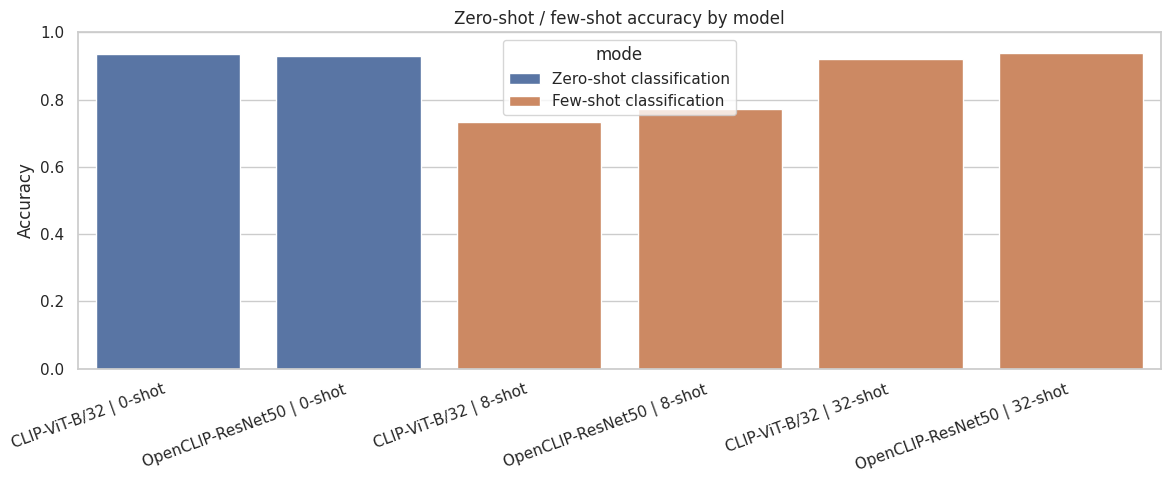

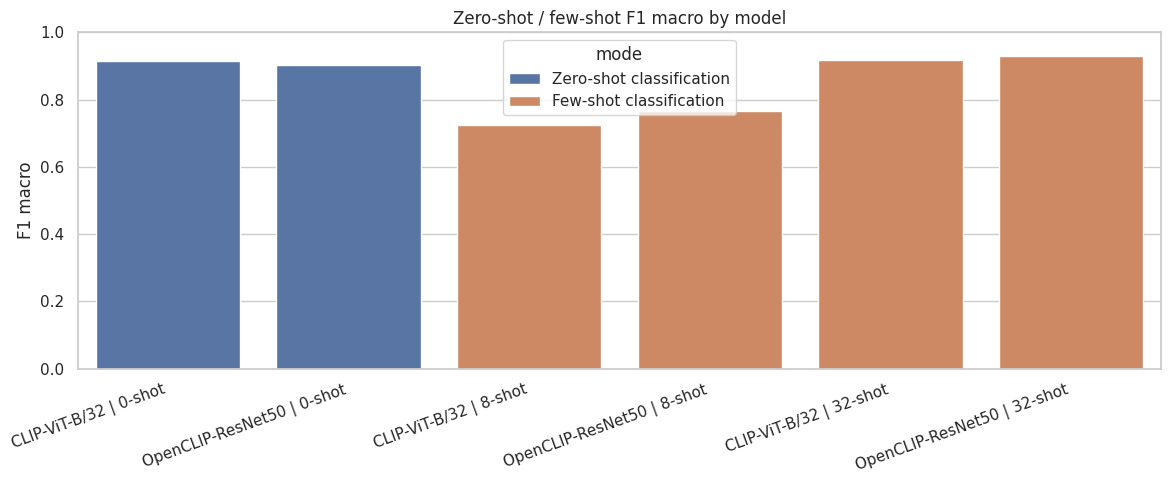

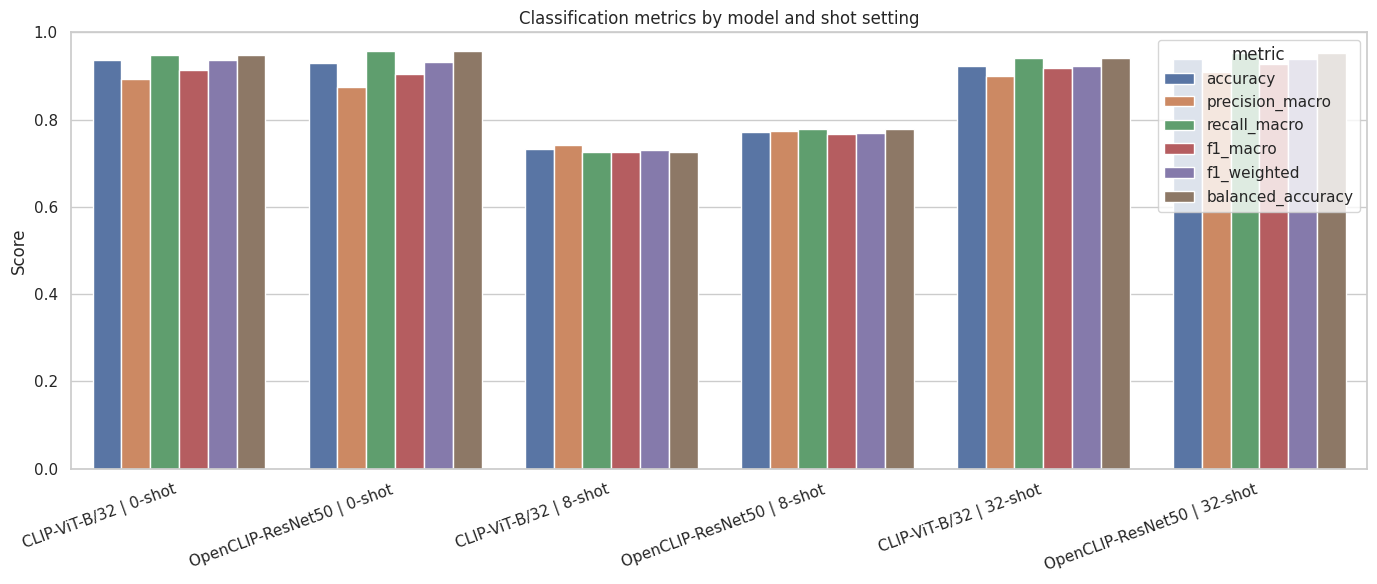

In [21]:
# 13. Comparison plots
if len(results_df) > 0:
    plot_df = results_df.copy()
    plot_df["setting"] = plot_df["model"] + " | " + plot_df["shots"].astype(str) + "-shot"

    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_df, x="setting", y="accuracy", hue="mode")
    plt.title("Zero-shot / few-shot accuracy by model")
    plt.xlabel("")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, min(1.0, max(0.1, plot_df["accuracy"].max() * 1.15)))
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "accuracy_comparison.png", dpi=160)
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_df, x="setting", y="f1_macro", hue="mode")
    plt.title("Zero-shot / few-shot F1 macro by model")
    plt.xlabel("")
    plt.ylabel("F1 macro")
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, min(1.0, max(0.1, plot_df["f1_macro"].max() * 1.15)))
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "f1_macro_comparison.png", dpi=160)
    plt.show()

    long_df = plot_df.melt(
        id_vars=["model", "shots", "mode", "setting"],
        value_vars=["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted", "balanced_accuracy"],
        var_name="metric",
        value_name="value",
    )
    plt.figure(figsize=(14, 6))
    sns.barplot(data=long_df, x="setting", y="value", hue="metric")
    plt.title("Classification metrics by model and shot setting")
    plt.xlabel("")
    plt.ylabel("Score")
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "classification_metrics_comparison.png", dpi=160)
    plt.show()


Best setting: ('OpenCLIP-ResNet50', 32)


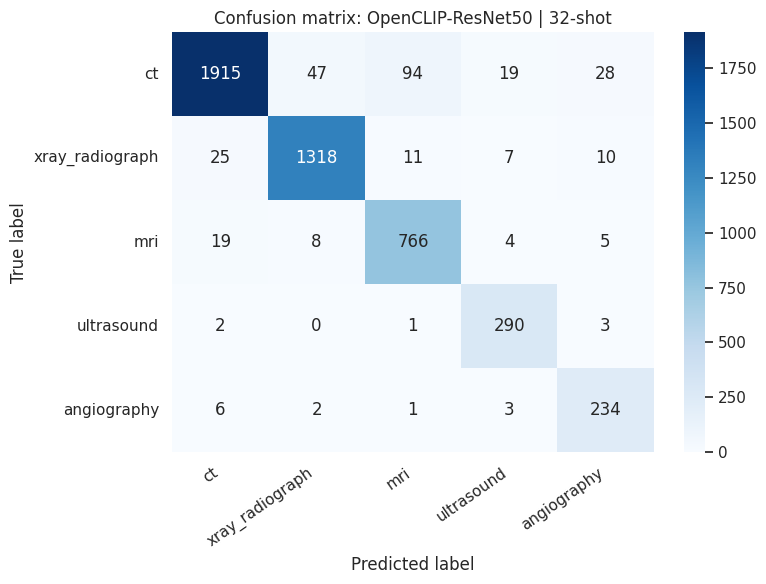

Hard cases / misclassified samples:


,sample_id,true_label,pred_label,caption,keywords
0,ROCO_00670,ct,mri,"Felis catus, adult, longitudinal section throu...","en,text,methodsseam,datum,abbreviation,middle,..."
1,ROCO_01154,ct,mri,The PET-CT image shows intense fluorine-18 flu...,"value,standardized,image,fluorine18,maximum,di..."
2,ROCO_01176,ct,mri,CT scan (frontal view) demonstrating multiple ...,"multiple,scan,frontal,air,arrow,view,locule,ct"
3,ROCO_01458,ct,mri,CT scan showing abscess formation beginning ar...,"absces,scan,sinu,formation,piriform,ct"
4,ROCO_01544,ct,mri,Chest computed tomography at the time of hospi...,"admissiona,right,nodule,hospital,subpleura,lob..."
5,ROCO_02584,ct,angiography,CT Angiography 24 h later showing normal coron...,"angiography,ct,normal,coronary"


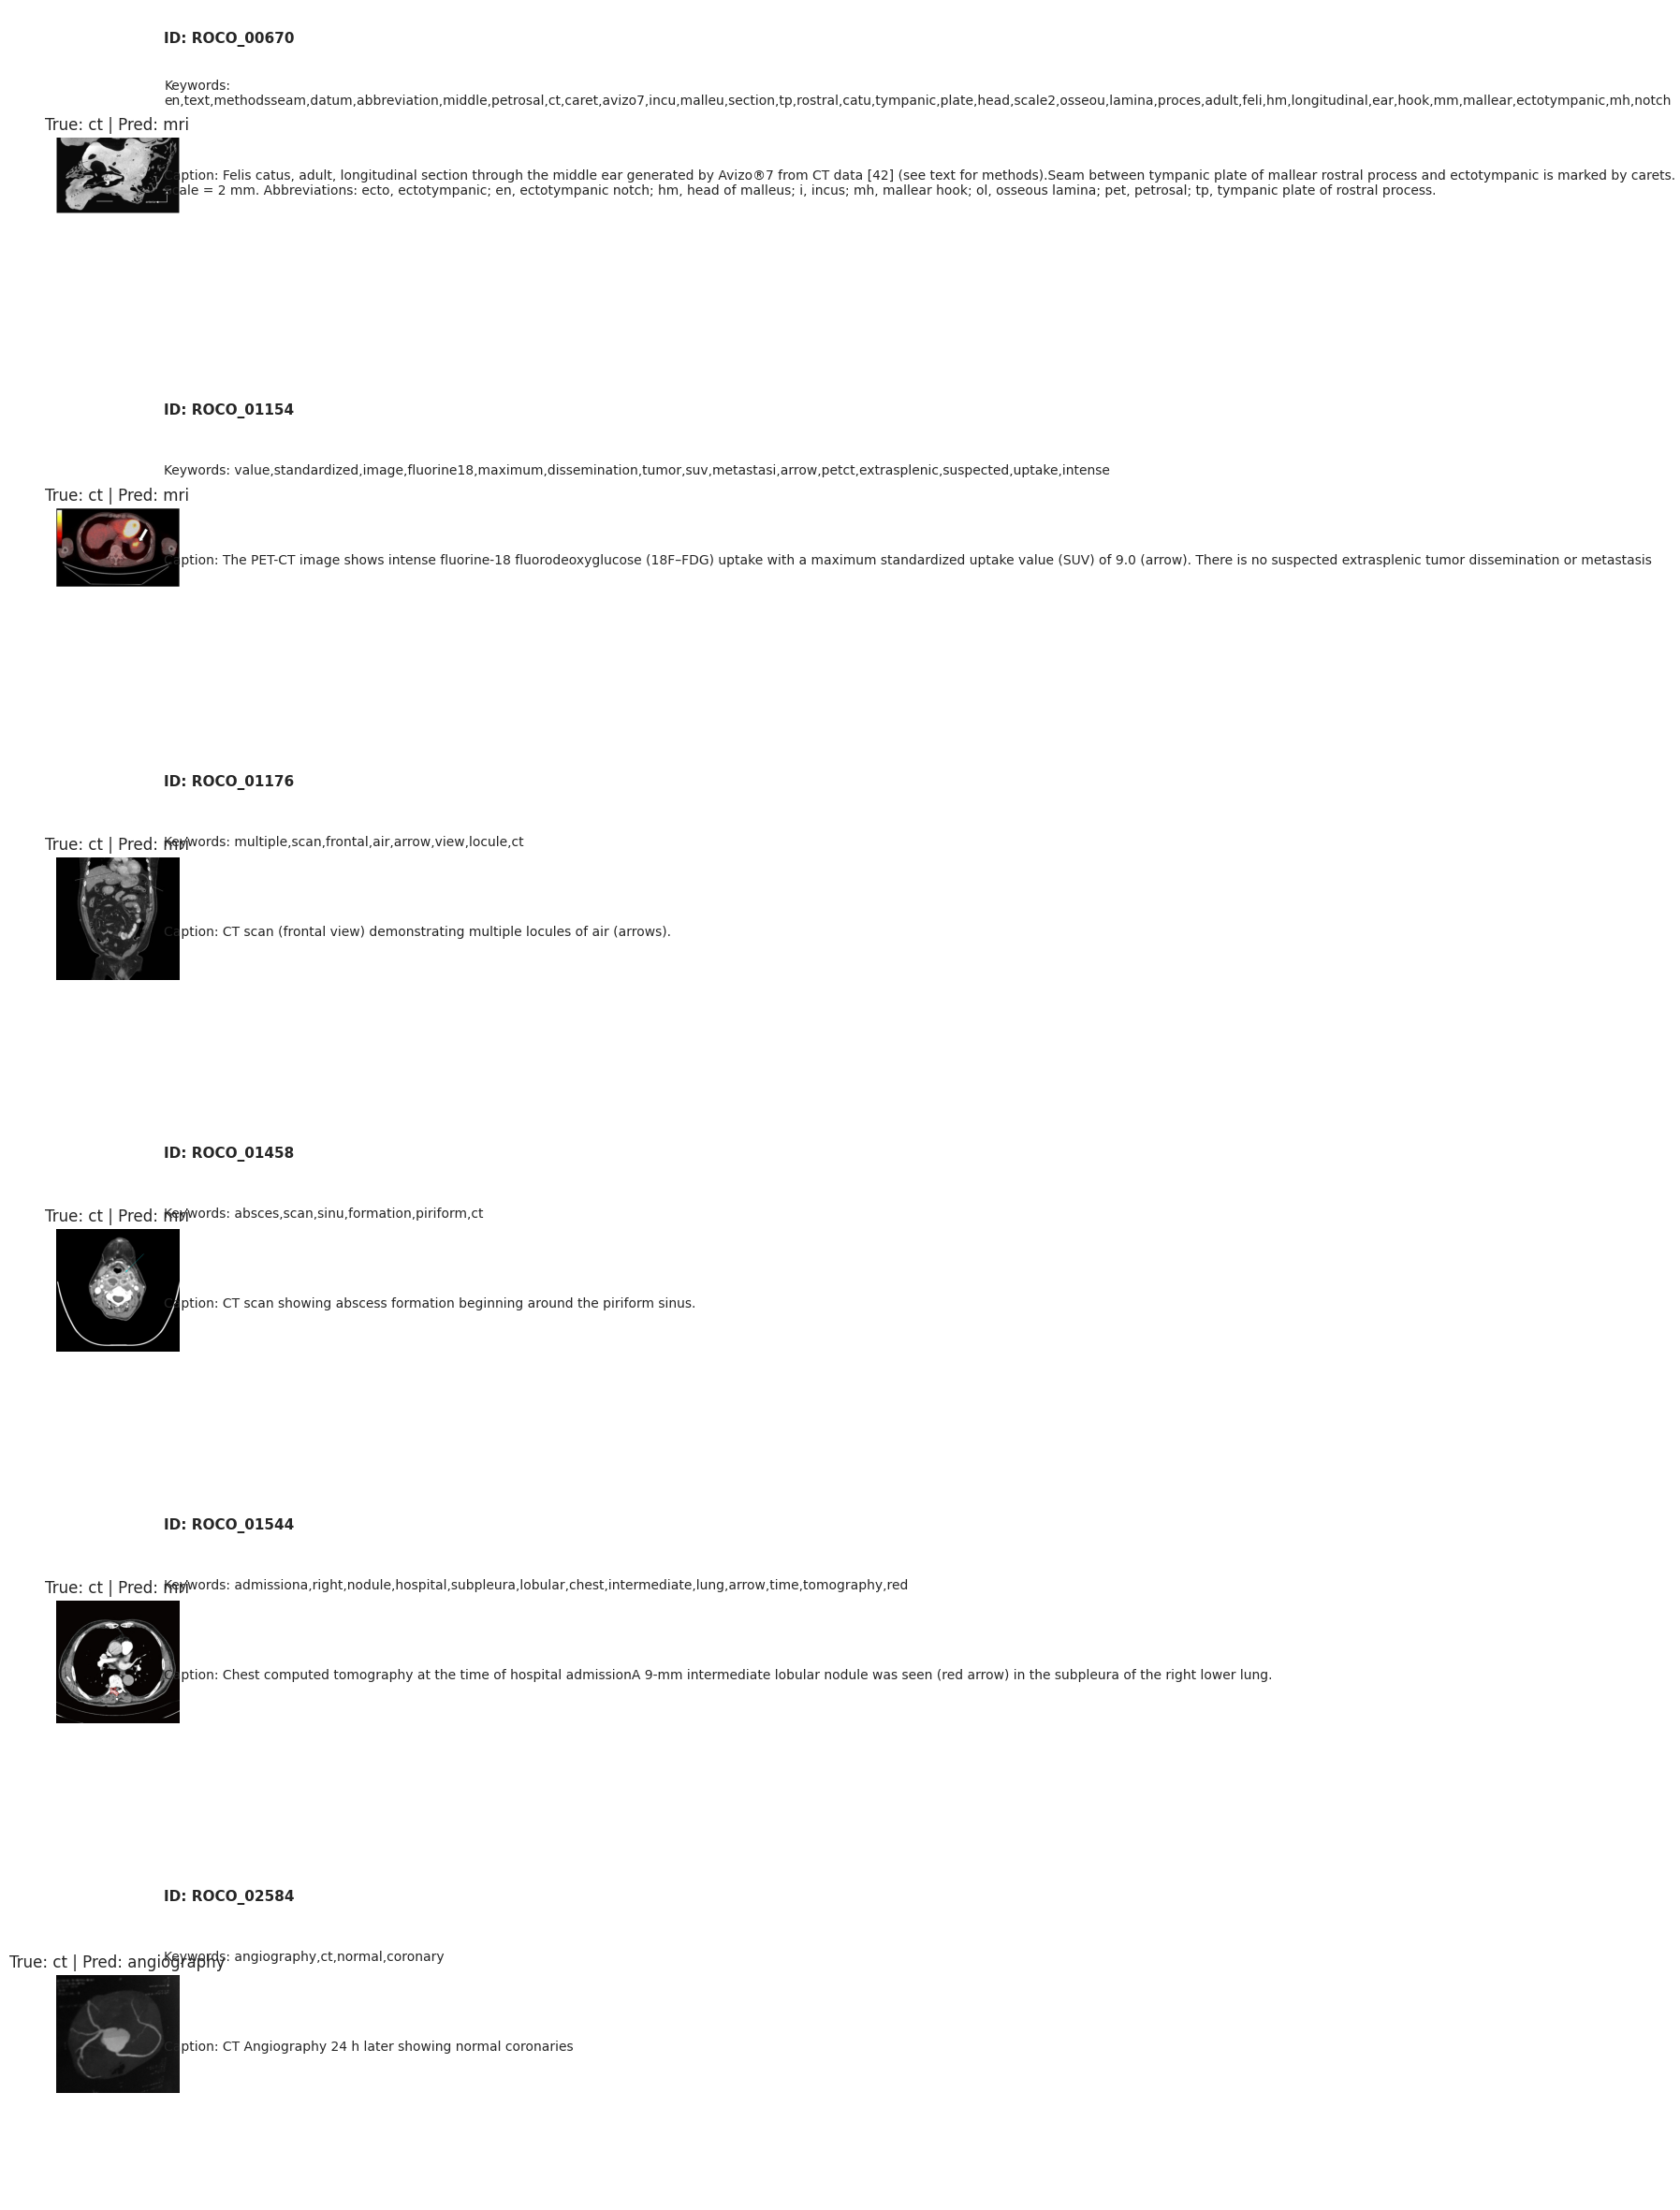

In [22]:
# 14. Confusion matrix and hard cases
if len(results_df) > 0:
    best_idx = results_df.sort_values(["f1_macro", "accuracy"], ascending=False).index[0]
    best_row = results_df.loc[best_idx]
    best_key = (best_row["model"], int(best_row["shots"]))
    best_pred = all_predictions.get(best_key)
    best_cm = all_confusions.get(best_key)

    print("Best setting:", best_key)
    if best_cm is not None:
        fname = f"confusion_matrix_best_{best_row['model'].lower().replace('/', '_').replace('-', '_')}_{int(best_row['shots'])}shot.png"
        plot_confusion(best_cm, f"Confusion matrix: {best_row['model']} | {int(best_row['shots'])}-shot", fname)

    if best_pred is not None:
        hard_cases = best_pred[~best_pred["is_correct"]].head(6).reset_index(drop=True)
        if len(hard_cases) == 0:
            print("No hard cases for this setting.")
        else:
            print("Hard cases / misclassified samples:")
            display(hard_cases[["sample_id", "true_label", "pred_label", "caption", "keywords"]].head(10))

            fig, axes = plt.subplots(len(hard_cases), 2, figsize=(14, 4 * len(hard_cases)))
            if len(hard_cases) == 1:
                axes = np.array([axes])
            for i, row in hard_cases.iterrows():
                img = Image.open(row["image_path"]).convert("RGB")
                axes[i, 0].imshow(img, cmap="gray")
                axes[i, 0].axis("off")
                axes[i, 0].set_title(f"True: {row['true_label']} | Pred: {row['pred_label']}")
                axes[i, 1].axis("off")
                axes[i, 1].text(0, 0.9, f"ID: {row['sample_id']}", fontsize=11, weight="bold")
                axes[i, 1].text(0, 0.72, f"Keywords: {str(row['keywords'])[:260]}", fontsize=10, wrap=True)
                axes[i, 1].text(0, 0.45, f"Caption: {str(row['caption'])[:520]}", fontsize=10, wrap=True)
            plt.tight_layout()
            plt.savefig(PLOT_DIR / "hard_cases_best_model.png", dpi=160)
            plt.show()


In [23]:
# 15. Per-class report preview
if len(results_df) > 0:
    for _, row in results_df.iterrows():
        model_name = row["model"]
        shots = int(row["shots"])
        slug = model_name.lower().replace("/", "_").replace("-", "_").replace(" ", "_")
        report_path = OUTDIR / f"classification_report_{slug}_{shots}shot.csv"
        if report_path.exists():
            print("=" * 90)
            print(model_name, shots, "shot")
            display(pd.read_csv(report_path).head(len(class_names) + 3))


CLIP-ViT-B/32 0 shot


,label,precision,recall,f1-score,support
0,ct,0.965932,0.916786,0.940717,2103.000000
1,xray_radiograph,0.945455,0.986142,0.965370,1371.000000
2,mri,0.982979,0.864090,0.919708,802.000000
3,ultrasound,0.909938,0.989865,0.948220,296.000000
4,angiography,0.665753,0.987805,0.795417,246.000000
5,accuracy,0.935866,0.935866,0.935866,0.935866
6,macro avg,0.894011,0.948937,0.913886,4818.000000
7,weighted avg,0.944176,0.935866,0.937277,4818.000000


OpenCLIP-ResNet50 0 shot


,label,precision,recall,f1-score,support
0,ct,0.990836,0.873990,0.928752,2103.000000
1,xray_radiograph,0.958601,0.979577,0.968975,1371.000000
2,mri,0.904192,0.941397,0.922419,802.000000
3,ultrasound,0.909657,0.986486,0.946515,296.000000
4,angiography,0.605911,1.000000,0.754601,246.000000
5,accuracy,0.928601,0.928601,0.928601,0.928601
6,macro avg,0.873839,0.956290,0.904253,4818.000000
7,weighted avg,0.942599,0.928601,0.931343,4818.000000


CLIP-ViT-B/32 8 shot


...

,label,precision,recall,f1-score,support
0,ct,0.778609,0.841179,0.808686,2103.000000
1,xray_radiograph,0.876180,0.609044,0.718589,1371.000000
2,mri,0.660470,0.841646,0.740132,802.000000
3,ultrasound,0.758333,0.922297,0.832317,296.000000
4,angiography,0.791469,0.678862,0.730853,246.000000
5,accuracy,0.771897,0.771897,0.771897,0.771897
6,macro avg,0.773012,0.778606,0.766115,4818.000000
7,weighted avg,0.786119,0.771897,0.769114,4818.000000


CLIP-ViT-B/32 32 shot


,label,precision,recall,f1-score,support
0,ct,0.947210,0.895863,0.920821,2103.000000
1,xray_radiograph,0.948454,0.939460,0.943936,1371.000000
2,mri,0.855006,0.926434,0.889288,802.000000
3,ultrasound,0.944262,0.972973,0.958403,296.000000
4,angiography,0.804714,0.971545,0.880295,246.000000
5,accuracy,0.921959,0.921959,0.921959,0.921959
6,macro avg,0.899929,0.941255,0.918548,4818.000000
7,weighted avg,0.924759,0.921959,0.922389,4818.000000


OpenCLIP-ResNet50 32 shot


,label,precision,recall,f1-score,support
0,ct,0.973564,0.910604,0.941032,2103.000000
1,xray_radiograph,0.958545,0.961342,0.959942,1371.000000
2,mri,0.877434,0.955112,0.914627,802.000000
3,ultrasound,0.897833,0.979730,0.936995,296.000000
4,angiography,0.835714,0.951220,0.889734,246.000000
5,accuracy,0.938771,0.938771,0.938771,0.938771
6,macro avg,0.908618,0.951601,0.928466,4818.000000
7,weighted avg,0.941598,0.938771,0.939150,4818.000000


In [24]:
# 16. Release artifact manifest and Streamlit skeleton
artifact_rows = []
for path in sorted(MODEL_DIR.glob("*")):
    artifact_rows.append({"type": "model", "path": str(path), "size_bytes": path.stat().st_size})
for path in sorted(OUTDIR.glob("*")):
    artifact_rows.append({"type": "output", "path": str(path), "size_bytes": path.stat().st_size})
for path in sorted(PLOT_DIR.glob("*")):
    artifact_rows.append({"type": "plot", "path": str(path), "size_bytes": path.stat().st_size})

artifact_df = pd.DataFrame(artifact_rows)
artifact_df.to_csv(OUTDIR / "artifact_manifest.csv", index=False)
display(artifact_df.head(30))

streamlit_code = '''
import pandas as pd
import streamlit as st

st.set_page_config(page_title="ROCO Classification", layout="wide")
st.title("ROCO Radiology Multimodal Classification")
st.caption("timm/resnet50_clip.openai vs CLIP ViT-B/32 | zero-shot vs few-shot classification")

results = pd.read_csv("outputs/model_comparison.csv")
st.subheader("Model comparison")
st.dataframe(results, use_container_width=True)

st.subheader("Accuracy and F1")
st.bar_chart(results.set_index(["model", "shots"])[["accuracy", "f1_macro", "f1_weighted"]])

st.subheader("Classification reports")
for _, row in results.iterrows():
    slug = row["model"].lower().replace("/", "_").replace("-", "_").replace(" ", "_")
    path = f"outputs/classification_report_{slug}_{int(row['shots'])}shot.csv"
    try:
        st.markdown(f"### {row['model']} | {int(row['shots'])}-shot")
        st.dataframe(pd.read_csv(path), use_container_width=True)
    except Exception:
        pass
'''
Path("streamlit_app.py").write_text(streamlit_code, encoding="utf-8")
print("Saved Streamlit skeleton: streamlit_app.py")


,type,path,size_bytes
0,model,models/classifier_clip_vit_b_32_16shot.pkl,19680
1,model,models/classifier_clip_vit_b_32_32shot.pkl,19680
2,model,models/classifier_clip_vit_b_32_8shot.pkl,19680
3,model,models/classifier_openclip_resnet50_16shot.pkl,19680
4,model,models/classifier_openclip_resnet50_32shot.pkl,19680
5,model,models/classifier_openclip_resnet50_8shot.pkl,19680
6,output,outputs/class_distribution.csv,302
7,output,outputs/classification_protocol.csv,894
8,output,outputs/classification_report_clip_vit_b_32_0s...,632
9,output,outputs/classification_report_clip_vit_b_32_16...,634


Saved Streamlit skeleton: streamlit_app.py


In [27]:
# Zip toàn bộ /kaggle/working để download artifact cuối cùng

from pathlib import Path
import shutil
import os

WORKING_DIR = Path("/kaggle/working")
ZIP_NAME = "roco_project_working_artifacts"
ZIP_BASE = WORKING_DIR / ZIP_NAME
ZIP_PATH = WORKING_DIR / f"{ZIP_NAME}.zip"

# Xóa zip cũ nếu đã tồn tại để tránh tự zip chính nó vào file mới
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

# Loại bớt cache/temporary folder nếu muốn zip nhẹ hơn
EXCLUDE_NAMES = {
    ".virtual_documents",
    "__pycache__",
    ".ipynb_checkpoints",
}

TMP_DIR = WORKING_DIR / "_zip_staging"
if TMP_DIR.exists():
    shutil.rmtree(TMP_DIR)
TMP_DIR.mkdir(parents=True, exist_ok=True)

# Copy các file/folder cần nộp sang staging
for item in WORKING_DIR.iterdir():
    if item.name in EXCLUDE_NAMES:
        continue
    if item.name == TMP_DIR.name:
        continue
    if item.name == ZIP_PATH.name:
        continue

    dest = TMP_DIR / item.name
    if item.is_dir():
        shutil.copytree(item, dest, ignore=shutil.ignore_patterns("__pycache__", ".ipynb_checkpoints"))
    else:
        shutil.copy2(item, dest)

# Tạo zip
created_zip = shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir=str(TMP_DIR)
)

# Xóa staging sau khi zip xong
shutil.rmtree(TMP_DIR)

zip_size_mb = os.path.getsize(created_zip) / (1024 * 1024)

print("Created ZIP:", created_zip)
print(f"ZIP size: {zip_size_mb:.2f} MB")
print("Download path:", ZIP_PATH)

# Hiển thị danh sách file chính trong zip
import zipfile

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    files = zf.namelist()
    print(f"Total files in zip: {len(files)}")
    print("First 30 files:")
    for f in files[:30]:
        print(" -", f)

Created ZIP: /kaggle/working/roco_project_working_artifacts.zip
ZIP size: 13.21 MB
Download path: /kaggle/working/roco_project_working_artifacts.zip
Total files in zip: 59
First 30 files:
 - docs/
 - models/
 - outputs/
 - streamlit_app.py
 - docs/plot/
 - docs/report_dashboard.md
 - docs/plot/confusion_matrix_best_openclip_resnet50_32shot.png
 - docs/plot/gradcam_openclip_resnet50_grid.png
 - docs/plot/hard_cases_best_model.png
 - docs/plot/model_comparison.json
 - docs/plot/accuracy_comparison.png
 - docs/plot/classification_metrics_comparison.png
 - docs/plot/eda_distribution.png
 - docs/plot/sample_pairs.png
 - docs/plot/f1_macro_comparison.png
 - outputs/classification_report_openclip_resnet50_8shot.csv
 - outputs/confusion_matrix_openclip_resnet50_0shot.csv
 - outputs/classification_report_clip_vit_b_32_8shot.csv
 - outputs/predictions_openclip_resnet50_32shot.csv
 - outputs/support_set_openclip_resnet50_8shot.csv
 - outputs/classification_report_openclip_resnet50_0shot.csv
 - ou

## Checklist báo cáo / video

1. Giới thiệu bài toán: ROCO Radiology là dataset đa phương thức gồm ảnh y khoa + caption/report text.
2. Nêu bài toán phân loại:
   - Input: image + caption.
   - Output: class label lấy từ **nhóm keyword đã lọc** trong cột `Keywords`.
3. Dataset processing:
   - `train_data.csv`, `val_data.csv`, `test_data.csv`, `images/...`
   - Lọc keyword **trước** khi tạo tập dùng cho train/validation/test.
   - Target classes mặc định: `ct`, `xray_radiograph`, `mri`, `ultrasound`, `angiography`.
   - Lưu thống kê lọc ở `outputs/keyword_filter_summary.csv` và `outputs/keyword_class_distribution.csv`.
   - Sau đó mới thống kê phân phối lớp và lấy few-shot support từ train split.
4. Mục 4.3:
   - So sánh **Zero-shot classification** và **Few-shot classification**.
   - OpenCLIP ResNet50: zero-shot bằng class prompts qua `open_clip`.
   - CLIP ViT-B/32: zero-shot bằng class prompts qua `transformers.AutoProcessor` + `AutoModelForZeroShotImageClassification`.
   - Few-shot: frozen image/text features + Logistic Regression với cùng số mẫu k-shot.
5. Mục 4.4:
   - Metric chính: accuracy + F1 macro.
   - Vì lớp có thể mất cân bằng: báo cáo thêm F1 weighted, precision, recall, balanced accuracy.
   - Hiển thị confusion matrix cho best model và lưu confusion matrix cho mọi cấu hình.
6. Model configuration:
   - ResNet branch: `hf-hub:timm/resnet50_clip.openai` qua `open_clip`.
   - CLIP ViT-B/32 branch: `openai/clip-vit-base-patch32` qua `transformers`.
   - Few-shot k = 8 samples/class.
7. Artifacts:
   - `outputs/model_comparison.csv`
   - `outputs/keyword_filter_summary.csv`
   - `outputs/keyword_class_distribution.csv`
   - `outputs/classification_report_*.csv`
   - `outputs/confusion_matrix_*.csv`
   - `docs/report_dashboard.md`
   - `docs/plot/*.png`
   - `models/classifier_*_8shot.pkl`
